# Representation Analysis: Mechanistic Evidence for Distillation Hypothesis

This notebook provides deep, representation-level analyses to investigate the "distillation hypothesis" - that negation understanding is compressed from BERT's layers 7/9 into DistilBERT's Layer 3.

## Core Analyses

1. **Representational Similarity Matrices (RSMs)** - Visualize how negation changes representations at each layer
2. **Probing the Probe** - Ablation studies to understand which neurons encode negation
3. **Cross-Model Consistency** - Canonical Correlation Analysis (CCA) between BERT and DistilBERT layers

## Prerequisites
Run this notebook **after** completing:
- `07_sweep_*.ipynb` (trained probes)
- `09_transfer_evaluation.ipynb` (transfer metrics)

## Key Outputs
- RSM heatmaps showing negation-induced representation changes
- Neuron ablation results identifying critical negation-encoding neurons
- CCA correlation matrices showing BERT→DistilBERT layer alignment
- Publication-ready figures for the distillation pathway


## 1. Setup & Configuration


In [70]:
#@title **Configure Environment** { display-mode: "form" }
import os
import psutil

# Check resources
print("=" * 60)
print("ENVIRONMENT CHECK")
print("=" * 60)

# RAM check
ram_gb = psutil.virtual_memory().total / 1e9
print(f"Available RAM: {ram_gb:.1f} GB")

if ram_gb > 25:
    print("  High-RAM mode detected")
    BATCH_SIZE = 64
else:
    print("  Standard RAM mode")
    BATCH_SIZE = 32

# GPU check
import torch
if torch.cuda.is_available():
    gpu_name = torch.cuda.get_device_name(0)
    gpu_mem = torch.cuda.get_device_properties(0).total_memory / 1e9
    print(f"GPU: {gpu_name} ({gpu_mem:.1f} GB)")
    DEVICE = "cuda"
else:
    print("No GPU detected, using CPU")
    DEVICE = "cpu"
    BATCH_SIZE = 16

print(f"\nConfiguration:")
print(f"  Device: {DEVICE}")
print(f"  Batch size: {BATCH_SIZE}")
print("=" * 60)


ENVIRONMENT CHECK
Available RAM: 13.6 GB
  Standard RAM mode
GPU: Tesla T4 (15.8 GB)

Configuration:
  Device: cuda
  Batch size: 32


In [71]:
# Mount Google Drive (for Colab)
try:
    from google.colab import drive
    drive.mount('/content/drive')
    IN_COLAB = True
except ImportError:
    IN_COLAB = False
    print("Running locally")


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [72]:
# Clone or pull the repository (Colab only)
if IN_COLAB:
    !git clone https://github.com/TheMattWang/Negation-Origin-Tracing.git 2>/dev/null || (cd Negation-Origin-Tracing && git pull)
    %cd Negation-Origin-Tracing


/content/Negation-Origin-Tracing/Negation-Origin-Tracing/Negation-Origin-Tracing


In [73]:
# Install dependencies
%pip install -q torch lightning transformers datasets pandas pyarrow matplotlib seaborn scikit-learn tqdm scipy

print("Dependencies installed. If this is the first run, restart the runtime now.")


Dependencies installed. If this is the first run, restart the runtime now.


In [74]:
# Set paths
import os
from datetime import datetime

if IN_COLAB:
    DRIVE_PATH = '/content/drive/MyDrive/NOT_results'
else:
    DRIVE_PATH = '../experiments'

OUTPUT_DIR = os.path.join(DRIVE_PATH, 'representation_analysis')
os.makedirs(OUTPUT_DIR, exist_ok=True)

print(f"Results from sweeps: {DRIVE_PATH}")
print(f"Output directory: {OUTPUT_DIR}")


Results from sweeps: /content/drive/MyDrive/NOT_results
Output directory: /content/drive/MyDrive/NOT_results/representation_analysis


In [75]:
# Core imports
import json
import glob
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from transformers import AutoModel, AutoTokenizer
from tqdm.auto import tqdm
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.cross_decomposition import CCA

# Publication-quality settings
plt.rcParams.update({
    'figure.figsize': (10, 6),
    'figure.dpi': 150,
    'font.size': 12,
    'axes.titlesize': 14,
    'axes.labelsize': 12,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
    'legend.fontsize': 10,
    'font.family': 'sans-serif',
    'axes.grid': True,
    'grid.alpha': 0.3,
})
sns.set_style("whitegrid")

# Color scheme
COLORS = {
    'anchor': '#3498db',      # Blue
    'negated': '#e74c3c',     # Red
    'layer3': '#f39c12',      # Gold (distillation target)
    'bert': '#9b59b6',        # Purple
    'distilbert': '#2ecc71',  # Green
    'highlight': '#f1c40f',   # Bright yellow
}

print("Imports and visualization settings configured.")


Imports and visualization settings configured.


## 2. Load Models and Data


In [76]:
# Load DistilBERT and BERT models
print("Loading models...")

# DistilBERT (6 layers)
DISTILBERT_NAME = "distilbert-base-uncased"
distilbert_tokenizer = AutoTokenizer.from_pretrained(DISTILBERT_NAME)
distilbert_model = AutoModel.from_pretrained(DISTILBERT_NAME)
distilbert_model = distilbert_model.to(DEVICE)
distilbert_model.eval()

print(f"DistilBERT loaded: {distilbert_model.config.num_hidden_layers} layers, {distilbert_model.config.hidden_size} hidden size")

# BERT-base (12 layers)
BERT_NAME = "bert-base-uncased"
bert_tokenizer = AutoTokenizer.from_pretrained(BERT_NAME)
bert_model = AutoModel.from_pretrained(BERT_NAME)
bert_model = bert_model.to(DEVICE)
bert_model.eval()

print(f"BERT loaded: {bert_model.config.num_hidden_layers} layers, {bert_model.config.hidden_size} hidden size")


Loading models...
DistilBERT loaded: 6 layers, 768 hidden size
BERT loaded: 12 layers, 768 hidden size


In [77]:
# Download negation dataset if needed
NEGATION_DATA_DIR = 'data/raw/negation'

if not os.path.exists(os.path.join(NEGATION_DATA_DIR, 'test.parquet')):
    print("Downloading JinaAI Negation Dataset...")
    !python src/data/download_negation.py --output_dir {NEGATION_DATA_DIR}
else:
    print("Negation dataset already exists!")

# Show dataset info
for split in ['train', 'test']:
    path = os.path.join(NEGATION_DATA_DIR, f'{split}.parquet')
    if os.path.exists(path):
        df = pd.read_parquet(path)
        print(f"  {split}: {len(df)} examples")


Error downloading dataset: Dataset scripts are no longer supported, but found negation-dataset-v2.py

Trying alternative approach...
Trying jinaai/negation-dataset...
Creating parquet from Arrow format: 100% 10/10 [00:00<00:00, 572.12ba/s]
  Saved train: 10000 examples -> /content/Negation-Origin-Tracing/Negation-Origin-Tracing/Negation-Origin-Tracing/data/raw/negation/train.parquet
Creating parquet from Arrow format: 100% 1/1 [00:00<00:00, 189.34ba/s]
  Saved test: 500 examples -> /content/Negation-Origin-Tracing/Negation-Origin-Tracing/Negation-Origin-Tracing/data/raw/negation/test.parquet

✓ Download complete!
  train: 10000 examples
  test: 500 examples


In [78]:
# Load negation dataset
import sys
sys.path.insert(0, '.')

from src.datasets.dataset import NegationTripletDataset
from torch.utils.data import DataLoader

# Use test split for evaluation
test_path = os.path.join(NEGATION_DATA_DIR, 'test.parquet')
if not os.path.exists(test_path):
    test_path = os.path.join(NEGATION_DATA_DIR, 'train.parquet')
    print("Using train split (test not found)")

negation_dataset = NegationTripletDataset(
    data_path=test_path,
    tokenizer=distilbert_tokenizer,
    max_length=128,
)

negation_loader = DataLoader(
    negation_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
)

print(f"\nLoaded {len(negation_dataset)} negation pairs")


[NegationTripletDataset] Loaded 500 pairs from test.parquet
  Sample anchor: This church choir sings to the masses as they sing joyous so...
  Sample negative: The church is empty of song....

Loaded 500 negation pairs


## 3. Feature Extraction Utilities


In [79]:
def extract_all_layer_features(model, tokenizer, texts, pooling='mean', device=DEVICE):
    """
    Extract features from all layers for a list of texts.

    Args:
        model: Transformer model (BERT or DistilBERT)
        tokenizer: Corresponding tokenizer
        texts: List of strings
        pooling: 'cls' or 'mean'
        device: Device to use

    Returns:
        dict: {layer_idx: tensor of shape (num_texts, hidden_size)}
    """
    model.eval()
    num_layers = model.config.num_hidden_layers

    # Tokenize all texts
    encodings = tokenizer(
        texts,
        padding=True,
        truncation=True,
        max_length=128,
        return_tensors='pt'
    )
    input_ids = encodings['input_ids'].to(device)
    attention_mask = encodings['attention_mask'].to(device)

    # Extract features
    with torch.no_grad():
        outputs = model(
            input_ids=input_ids,
            attention_mask=attention_mask,
            output_hidden_states=True
        )

    hidden_states = outputs.hidden_states  # Tuple of (batch, seq_len, hidden)

    layer_features = {}
    for layer_idx in range(num_layers):
        # hidden_states[0] is embeddings, hidden_states[1] is layer 0, etc.
        layer_hidden = hidden_states[layer_idx + 1]

        if pooling == 'cls':
            pooled = layer_hidden[:, 0, :]
        elif pooling == 'mean':
            mask_expanded = attention_mask.unsqueeze(-1).expand(layer_hidden.size()).float()
            sum_hidden = torch.sum(layer_hidden * mask_expanded, dim=1)
            sum_mask = torch.clamp(mask_expanded.sum(dim=1), min=1e-9)
            pooled = sum_hidden / sum_mask
        else:
            raise ValueError(f"Unknown pooling: {pooling}")

        layer_features[layer_idx] = pooled.cpu()

    return layer_features


def extract_paired_features(model, tokenizer, anchor_texts, negative_texts, pooling='mean', device=DEVICE):
    """
    Extract features for anchor-negative pairs from all layers.

    Returns:
        tuple: (anchor_features_dict, negative_features_dict)
    """
    anchor_features = extract_all_layer_features(model, tokenizer, anchor_texts, pooling, device)
    negative_features = extract_all_layer_features(model, tokenizer, negative_texts, pooling, device)
    return anchor_features, negative_features

print("Feature extraction utilities defined.")


Feature extraction utilities defined.


In [80]:
# Extract sample data for analysis
# Use different sample sizes for different analyses:
# - RSM visualization: 100 samples (for clear heatmaps)
# - CCA analysis: 500+ samples (for stable cross-model correlation)

N_SAMPLES_VIS = min(100, len(negation_dataset))  # For RSM visualization
N_SAMPLES_CCA = min(500, len(negation_dataset))  # For CCA (need more samples for stability)
N_SAMPLES = N_SAMPLES_CCA  # Use larger sample for feature extraction

print(f"Dataset size: {len(negation_dataset)} pairs")
print(f"Using {N_SAMPLES_VIS} samples for RSM visualization")
print(f"Using {N_SAMPLES_CCA} samples for CCA analysis")
print(f"\nExtracting features for {N_SAMPLES} pairs...")

# Get raw texts
anchor_texts = []
negative_texts = []

for i in range(N_SAMPLES):
    raw = negation_dataset.get_raw_texts(i)
    anchor_texts.append(raw['anchor'])
    negative_texts.append(raw['negative'])

print(f"Sample anchor: {anchor_texts[0][:60]}...")
print(f"Sample negative: {negative_texts[0][:60]}...")

# Extract features for DistilBERT
print("\nExtracting DistilBERT features...")
distilbert_anchor_features, distilbert_negative_features = extract_paired_features(
    distilbert_model, distilbert_tokenizer, anchor_texts, negative_texts, pooling='mean'
)

# Extract features for BERT
print("Extracting BERT features...")
bert_anchor_features, bert_negative_features = extract_paired_features(
    bert_model, bert_tokenizer, anchor_texts, negative_texts, pooling='mean'
)

print(f"\nDistilBERT: {len(distilbert_anchor_features)} layers, {distilbert_anchor_features[0].shape[0]} samples each")
print(f"BERT: {len(bert_anchor_features)} layers, {bert_anchor_features[0].shape[0]} samples each")


Dataset size: 500 pairs
Using 100 samples for RSM visualization
Using 500 samples for CCA analysis

Extracting features for 500 pairs...
Sample anchor: This church choir sings to the masses as they sing joyous so...
Sample negative: The church is empty of song....

Extracting DistilBERT features...
Extracting BERT features...

DistilBERT: 6 layers, 500 samples each
BERT: 12 layers, 500 samples each


## 4. Analysis 1: Representational Similarity Matrices (RSMs)

For each layer, we compute the cosine similarity matrix between all sentence representations.

**Expected Pattern:**
- High similarity within anchor group (upper-left block)
- High similarity within negated group (lower-right block)
- **Lower similarity between anchor and negated blocks** (off-diagonal)
- The contrast should be **maximal at the layer where negation is most distinctly encoded** (Layer 3 for DistilBERT)


In [81]:
def compute_rsm(features_a, features_b):
    """
    Compute Representational Similarity Matrix using cosine similarity.

    Args:
        features_a: Tensor of shape (N, hidden_size)
        features_b: Tensor of shape (M, hidden_size)

    Returns:
        Cosine similarity matrix of shape (N, M)
    """
    # Normalize
    a_norm = F.normalize(features_a, p=2, dim=1)
    b_norm = F.normalize(features_b, p=2, dim=1)

    # Compute cosine similarity
    sim_matrix = torch.mm(a_norm, b_norm.t())
    return sim_matrix.numpy()


def compute_block_rsm(anchor_features, negative_features):
    """
    Compute full RSM with block structure: [anchors, negatives].

    Returns:
        rsm: Full similarity matrix
        within_anchor: Mean similarity within anchor block
        within_negative: Mean similarity within negative block
        between_blocks: Mean similarity between anchor and negative blocks
    """
    # Concatenate features
    all_features = torch.cat([anchor_features, negative_features], dim=0)
    n_anchors = anchor_features.shape[0]

    # Compute full RSM
    rsm = compute_rsm(all_features, all_features)

    # Extract blocks
    anchor_block = rsm[:n_anchors, :n_anchors]
    negative_block = rsm[n_anchors:, n_anchors:]
    cross_block = rsm[:n_anchors, n_anchors:]

    # Compute mean similarities (excluding diagonal for within-block)
    within_anchor = np.mean(anchor_block[np.triu_indices(n_anchors, k=1)])
    within_negative = np.mean(negative_block[np.triu_indices(n_anchors, k=1)])
    between_blocks = np.mean(cross_block)

    return rsm, within_anchor, within_negative, between_blocks

print("RSM computation functions defined.")


RSM computation functions defined.


In [82]:
# Compute RSMs for all DistilBERT layers
# Use N_SAMPLES_VIS for visualization (smaller, cleaner heatmaps)
print(f"Computing RSMs for DistilBERT layers (using first {N_SAMPLES_VIS} samples for visualization)...")

distilbert_rsm_stats = []

for layer_idx in range(6):
    # Use only first N_SAMPLES_VIS for RSM visualization
    rsm, within_a, within_n, between = compute_block_rsm(
        distilbert_anchor_features[layer_idx][:N_SAMPLES_VIS],
        distilbert_negative_features[layer_idx][:N_SAMPLES_VIS]
    )

    # Block contrast: how much lower is between-block similarity vs within-block
    avg_within = (within_a + within_n) / 2
    contrast = avg_within - between

    distilbert_rsm_stats.append({
        'layer': layer_idx,
        'within_anchor': within_a,
        'within_negative': within_n,
        'between_blocks': between,
        'contrast': contrast,
        'rsm': rsm
    })

    print(f"  Layer {layer_idx}: within={avg_within:.4f}, between={between:.4f}, contrast={contrast:.4f}")

# Find layer with maximum contrast
max_contrast_layer = max(distilbert_rsm_stats, key=lambda x: x['contrast'])['layer']
print(f"\n→ Maximum contrast at Layer {max_contrast_layer}")


Computing RSMs for DistilBERT layers (using first 100 samples for visualization)...
  Layer 0: within=0.7936, between=0.7617, contrast=0.0319
  Layer 1: within=0.8509, between=0.8201, contrast=0.0309
  Layer 2: within=0.8956, between=0.8722, contrast=0.0235
  Layer 3: within=0.9077, between=0.8867, contrast=0.0210
  Layer 4: within=0.8952, between=0.8770, contrast=0.0182
  Layer 5: within=0.7789, between=0.7380, contrast=0.0409

→ Maximum contrast at Layer 5


/tmp/ipython-input-2087169119.py:35: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


Saved: /content/drive/MyDrive/NOT_results/representation_analysis/rsm_all_layers.png


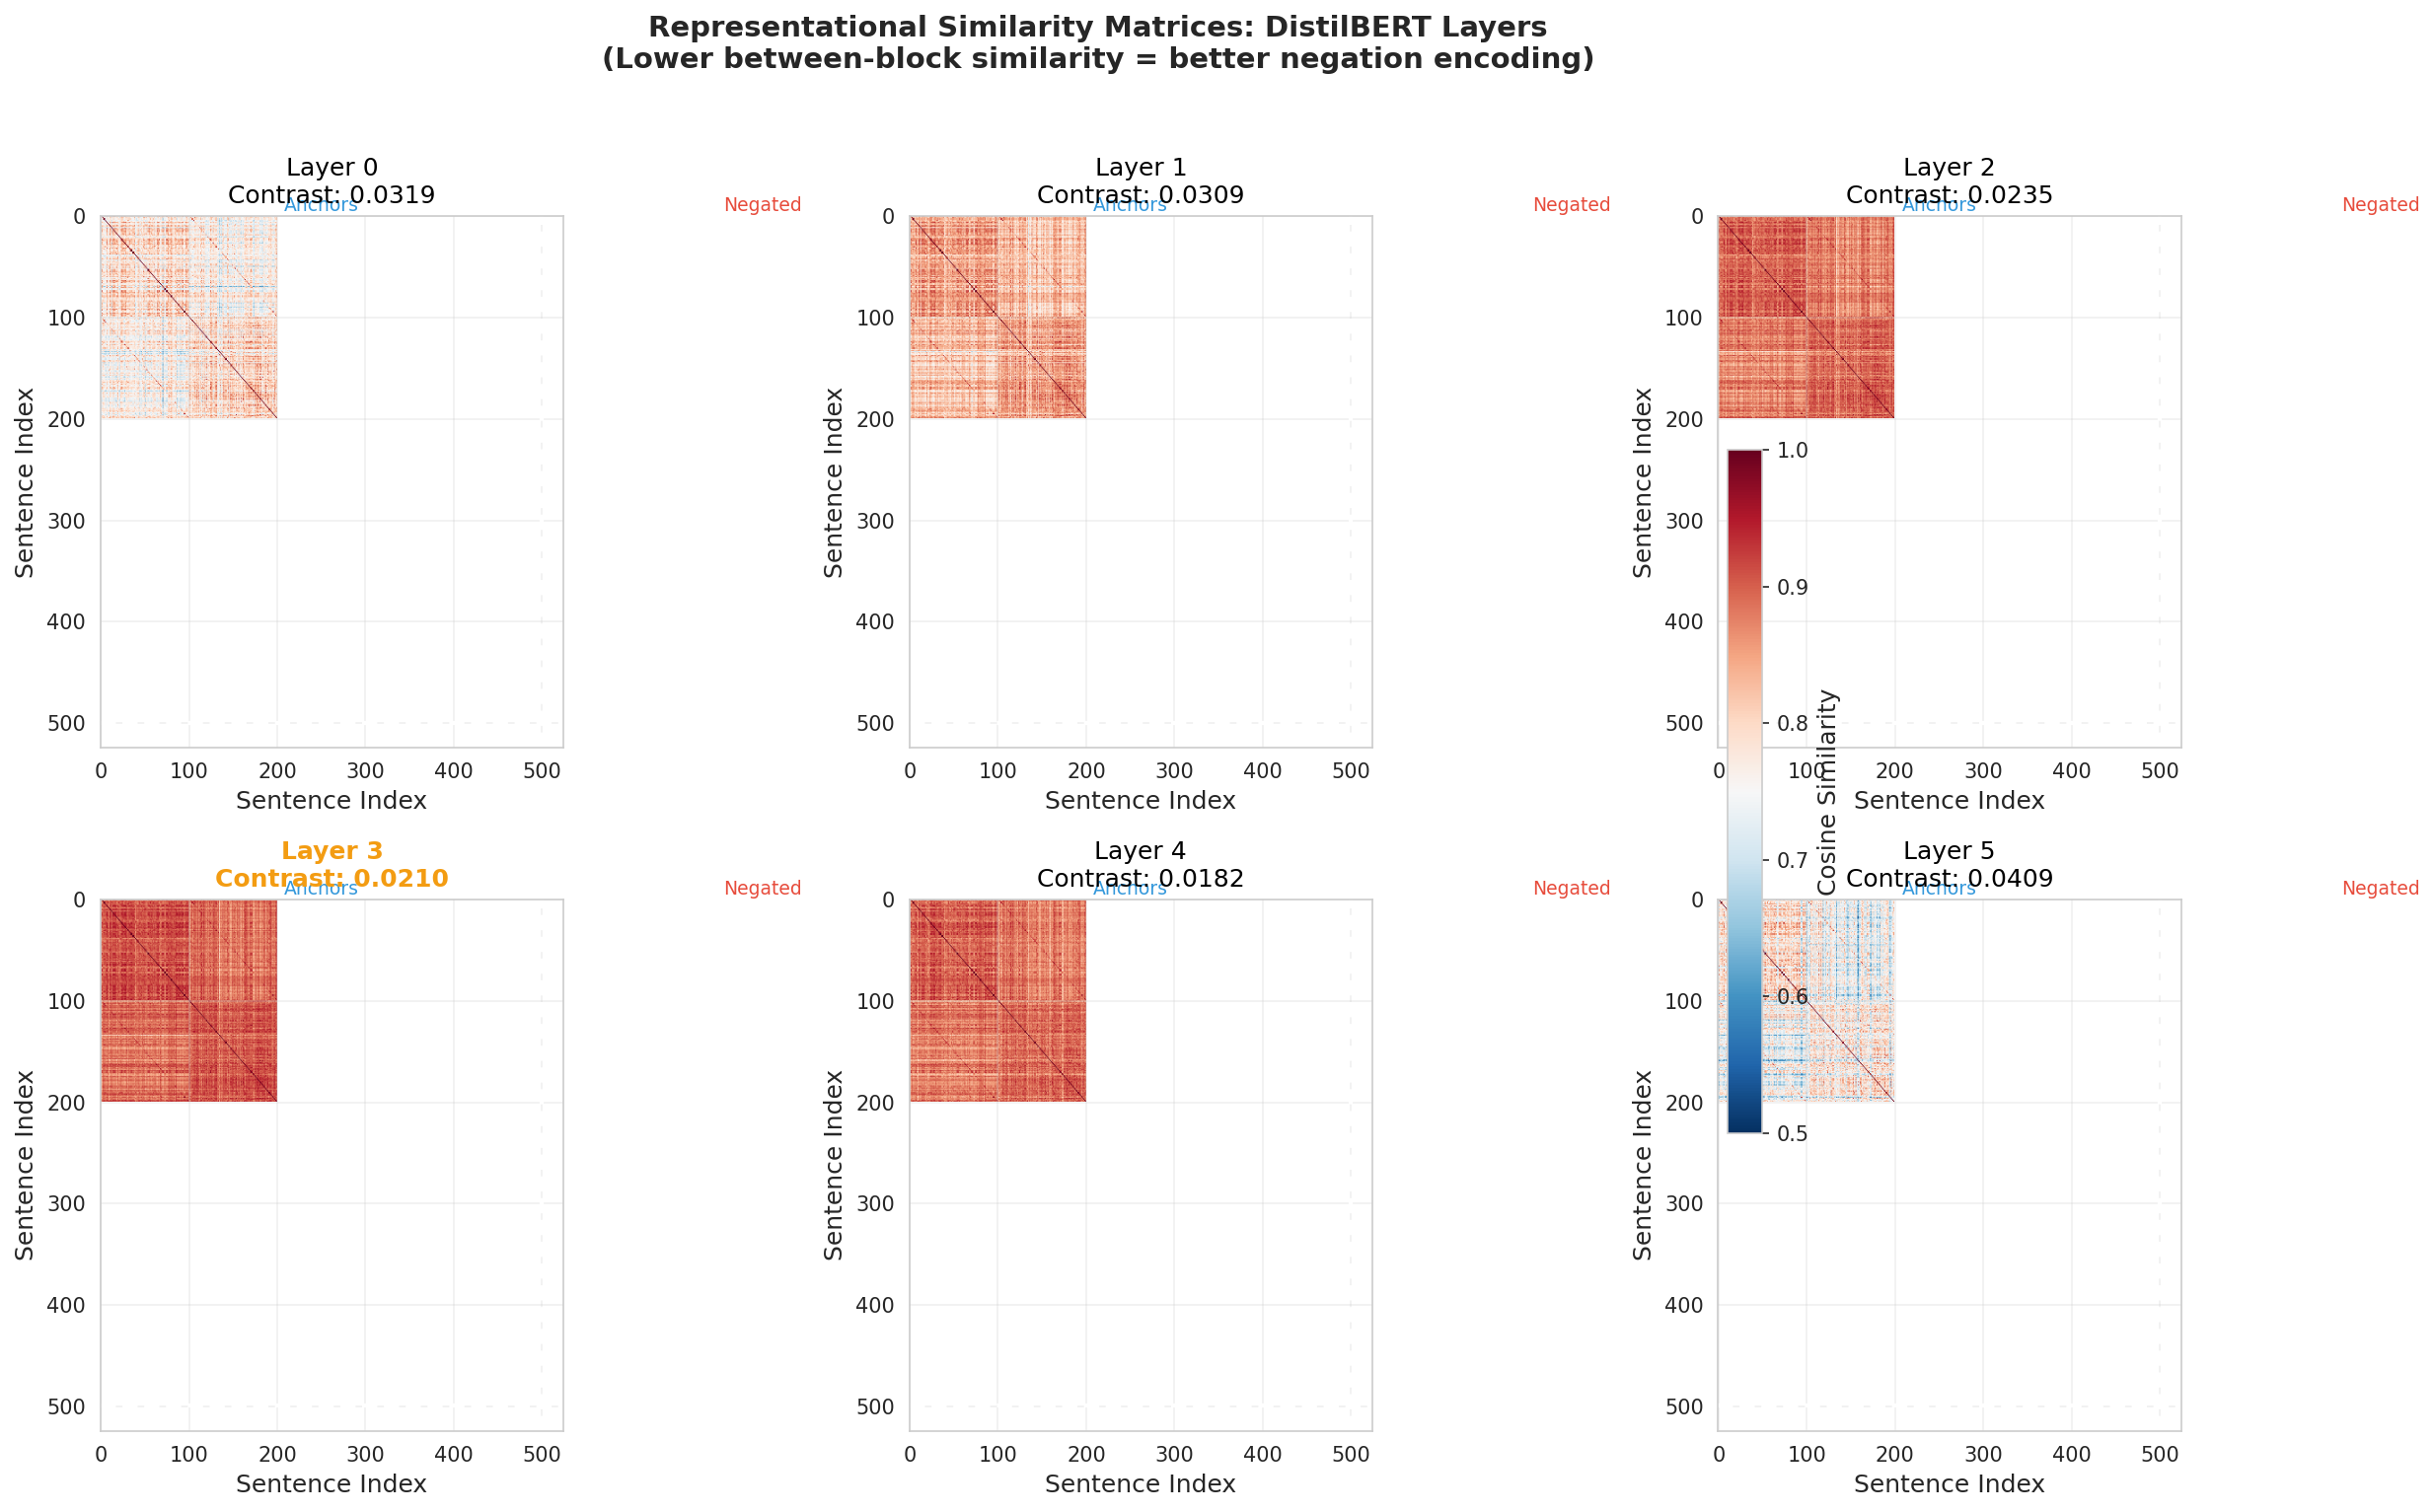

In [83]:
# Visualize RSMs for key layers
fig, axes = plt.subplots(2, 3, figsize=(15, 10))

for idx, layer_idx in enumerate(range(6)):
    ax = axes[idx // 3, idx % 3]
    rsm = distilbert_rsm_stats[layer_idx]['rsm']
    contrast = distilbert_rsm_stats[layer_idx]['contrast']

    # Plot heatmap
    im = ax.imshow(rsm, cmap='RdBu_r', vmin=0.5, vmax=1.0, aspect='auto')

    # Add block boundary
    n = N_SAMPLES
    ax.axhline(y=n-0.5, color='white', linewidth=2, linestyle='--')
    ax.axvline(x=n-0.5, color='white', linewidth=2, linestyle='--')

    # Highlight Layer 3
    title_color = COLORS['layer3'] if layer_idx == 3 else 'black'
    title_weight = 'bold' if layer_idx == 3 else 'normal'

    ax.set_title(f'Layer {layer_idx}\nContrast: {contrast:.4f}',
                 fontsize=12, fontweight=title_weight, color=title_color)
    ax.set_xlabel('Sentence Index')
    ax.set_ylabel('Sentence Index')

    # Add block labels
    ax.text(n//2, -5, 'Anchors', ha='center', fontsize=9, color=COLORS['anchor'])
    ax.text(n + n//2, -5, 'Negated', ha='center', fontsize=9, color=COLORS['negated'])

# Add colorbar
fig.colorbar(im, ax=axes.ravel().tolist(), label='Cosine Similarity', shrink=0.6)

plt.suptitle('Representational Similarity Matrices: DistilBERT Layers\n(Lower between-block similarity = better negation encoding)',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()

# Save figure
save_path = os.path.join(OUTPUT_DIR, 'rsm_all_layers.png')
plt.savefig(save_path, dpi=300, bbox_inches='tight', facecolor='white')
print(f"Saved: {save_path}")

plt.show()


Saved: /content/drive/MyDrive/NOT_results/representation_analysis/rsm_contrast_by_layer.png


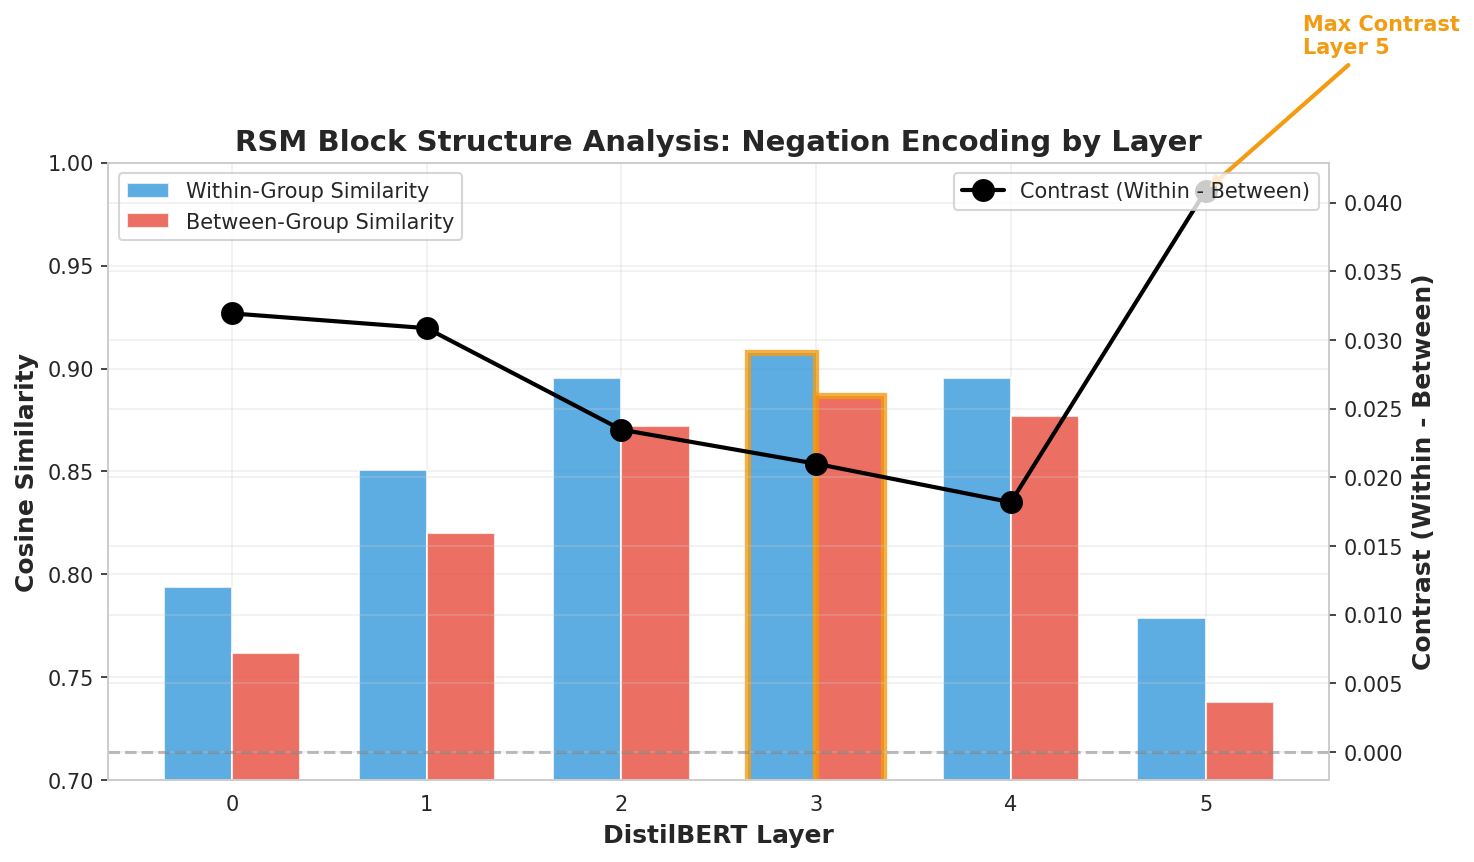

In [84]:
# Plot RSM contrast by layer
fig, ax = plt.subplots(figsize=(10, 6))

layers = [s['layer'] for s in distilbert_rsm_stats]
contrasts = [s['contrast'] for s in distilbert_rsm_stats]
within_sims = [(s['within_anchor'] + s['within_negative']) / 2 for s in distilbert_rsm_stats]
between_sims = [s['between_blocks'] for s in distilbert_rsm_stats]

# Plot bars
x = np.arange(len(layers))
width = 0.35

bars1 = ax.bar(x - width/2, within_sims, width, label='Within-Group Similarity',
               color=COLORS['anchor'], alpha=0.8)
bars2 = ax.bar(x + width/2, between_sims, width, label='Between-Group Similarity',
               color=COLORS['negated'], alpha=0.8)

# Highlight Layer 3
bars1[3].set_edgecolor(COLORS['layer3'])
bars1[3].set_linewidth(3)
bars2[3].set_edgecolor(COLORS['layer3'])
bars2[3].set_linewidth(3)

# Add contrast line
ax2 = ax.twinx()
ax2.plot(x, contrasts, 'ko-', linewidth=2, markersize=10, label='Contrast (Within - Between)')
ax2.axhline(y=0, color='gray', linestyle='--', alpha=0.5)

# Mark maximum contrast
max_idx = np.argmax(contrasts)
ax2.annotate(f'Max Contrast\nLayer {max_idx}',
             xy=(max_idx, contrasts[max_idx]),
             xytext=(max_idx + 0.5, contrasts[max_idx] + 0.01),
             arrowprops=dict(arrowstyle='->', color=COLORS['layer3'], lw=2),
             fontsize=10, fontweight='bold', color=COLORS['layer3'])

# Formatting
ax.set_xlabel('DistilBERT Layer', fontsize=12, fontweight='bold')
ax.set_ylabel('Cosine Similarity', fontsize=12, fontweight='bold')
ax2.set_ylabel('Contrast (Within - Between)', fontsize=12, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(layers)
ax.set_ylim(0.7, 1.0)
ax.legend(loc='upper left')
ax2.legend(loc='upper right')

plt.title('RSM Block Structure Analysis: Negation Encoding by Layer', fontsize=14, fontweight='bold')
plt.tight_layout()

save_path = os.path.join(OUTPUT_DIR, 'rsm_contrast_by_layer.png')
plt.savefig(save_path, dpi=300, bbox_inches='tight', facecolor='white')
print(f"Saved: {save_path}")

plt.show()


## 5. Analysis 2: Probing the Probe - Neuron Ablation Study

This analysis investigates which neurons in Layer 3 are critical for negation encoding.

**Method:**
1. For sentences where the probe correctly flips prediction, zero-out specific neurons
2. Measure if flip accuracy drops dramatically
3. Compare with other layers as control

**Expected Result:**
- Layer 3 should be most sensitive to neuron ablation
- A small subset of neurons may be disproportionately important


In [85]:
# Load trained probes for ablation study
from src.models import BaseModule

def load_probe_checkpoint(layer_idx, pooling='mean'):
    """Load trained probe from sweep results."""
    sweep_dir = os.path.join(DRIVE_PATH, f'sweep_{pooling}')

    # Try different checkpoint patterns
    patterns = [
        os.path.join(sweep_dir, 'checkpoints', f'layer{layer_idx}_{pooling}', 'best*.ckpt'),
        os.path.join(sweep_dir, f'layer_{layer_idx}_pooling_{pooling}', 'checkpoints', 'best*.ckpt'),
    ]

    for pattern in patterns:
        matches = glob.glob(pattern)
        if matches:
            checkpoint_path = matches[0]
            model = BaseModule.load_from_checkpoint(
                checkpoint_path,
                model_name=DISTILBERT_NAME,
                mode="probe",
                probe_layer=layer_idx,
                pooling_strategy=pooling,
            )
            model = model.to(DEVICE)
            model.eval()
            return model

    print(f"Warning: No checkpoint found for layer {layer_idx}, pooling {pooling}")
    return None

print("Probe loading function defined.")


Probe loading function defined.


In [86]:
def ablation_experiment(model, layer_idx, anchor_features, negative_features,
                        ablation_fraction=0.1, n_trials=10):
    """
    Perform neuron ablation experiment.

    Args:
        model: Trained probe model
        layer_idx: Layer being probed
        anchor_features: Anchor sentence features
        negative_features: Negative sentence features
        ablation_fraction: Fraction of neurons to ablate
        n_trials: Number of random ablation trials

    Returns:
        dict with baseline and ablated flip accuracies
    """
    probe = model.probes[f"layer_{layer_idx}"]
    hidden_size = anchor_features.shape[1]
    n_ablate = int(hidden_size * ablation_fraction)

    # Move features to device
    anchor_feat = anchor_features.to(DEVICE)
    negative_feat = negative_features.to(DEVICE)

    with torch.no_grad():
        # Baseline predictions
        anchor_logits = probe(anchor_feat)
        negative_logits = probe(negative_feat)

        anchor_preds = torch.argmax(anchor_logits, dim=-1)
        negative_preds = torch.argmax(negative_logits, dim=-1)

        baseline_flips = (anchor_preds != negative_preds).float()
        baseline_flip_acc = baseline_flips.mean().item()

        # Random ablation trials
        ablated_flip_accs = []

        for trial in range(n_trials):
            # Random neurons to ablate
            ablate_indices = np.random.choice(hidden_size, n_ablate, replace=False)

            # Create ablated features
            anchor_ablated = anchor_feat.clone()
            negative_ablated = negative_feat.clone()
            anchor_ablated[:, ablate_indices] = 0
            negative_ablated[:, ablate_indices] = 0

            # Get predictions
            anchor_logits_abl = probe(anchor_ablated)
            negative_logits_abl = probe(negative_ablated)

            anchor_preds_abl = torch.argmax(anchor_logits_abl, dim=-1)
            negative_preds_abl = torch.argmax(negative_logits_abl, dim=-1)

            ablated_flips = (anchor_preds_abl != negative_preds_abl).float()
            ablated_flip_accs.append(ablated_flips.mean().item())

    return {
        'layer': layer_idx,
        'baseline_flip_acc': baseline_flip_acc,
        'ablated_flip_acc_mean': np.mean(ablated_flip_accs),
        'ablated_flip_acc_std': np.std(ablated_flip_accs),
        'accuracy_drop': baseline_flip_acc - np.mean(ablated_flip_accs),
        'n_neurons_ablated': n_ablate,
    }

print("Ablation experiment function defined.")


Ablation experiment function defined.


In [87]:
# Run ablation experiments for all layers
print("Running ablation experiments...")
print("(This may take a few minutes)\n")

ablation_results = []

for layer_idx in range(6):
    print(f"Layer {layer_idx}...", end=" ")

    # Load probe
    model = load_probe_checkpoint(layer_idx, pooling='mean')

    if model is None:
        print("SKIPPED (no checkpoint)")
        continue

    # Run ablation
    result = ablation_experiment(
        model, layer_idx,
        distilbert_anchor_features[layer_idx],
        distilbert_negative_features[layer_idx],
        ablation_fraction=0.1,
        n_trials=20
    )
    ablation_results.append(result)

    print(f"baseline={result['baseline_flip_acc']:.3f}, ablated={result['ablated_flip_acc_mean']:.3f} (±{result['ablated_flip_acc_std']:.3f})")

    # Clean up
    del model
    if DEVICE == "cuda":
        torch.cuda.empty_cache()

print("\nAblation experiments complete.")


Running ablation experiments...
(This may take a few minutes)

Layer 0... baseline=0.378, ablated=0.387 (±0.048)
Layer 1... baseline=0.352, ablated=0.344 (±0.072)
Layer 2... baseline=0.334, ablated=0.317 (±0.081)
Layer 3... baseline=0.422, ablated=0.446 (±0.079)
Layer 4... baseline=0.380, ablated=0.366 (±0.088)
Layer 5... baseline=0.352, ablated=0.344 (±0.082)

Ablation experiments complete.


Saved: /content/drive/MyDrive/NOT_results/representation_analysis/ablation_study.png


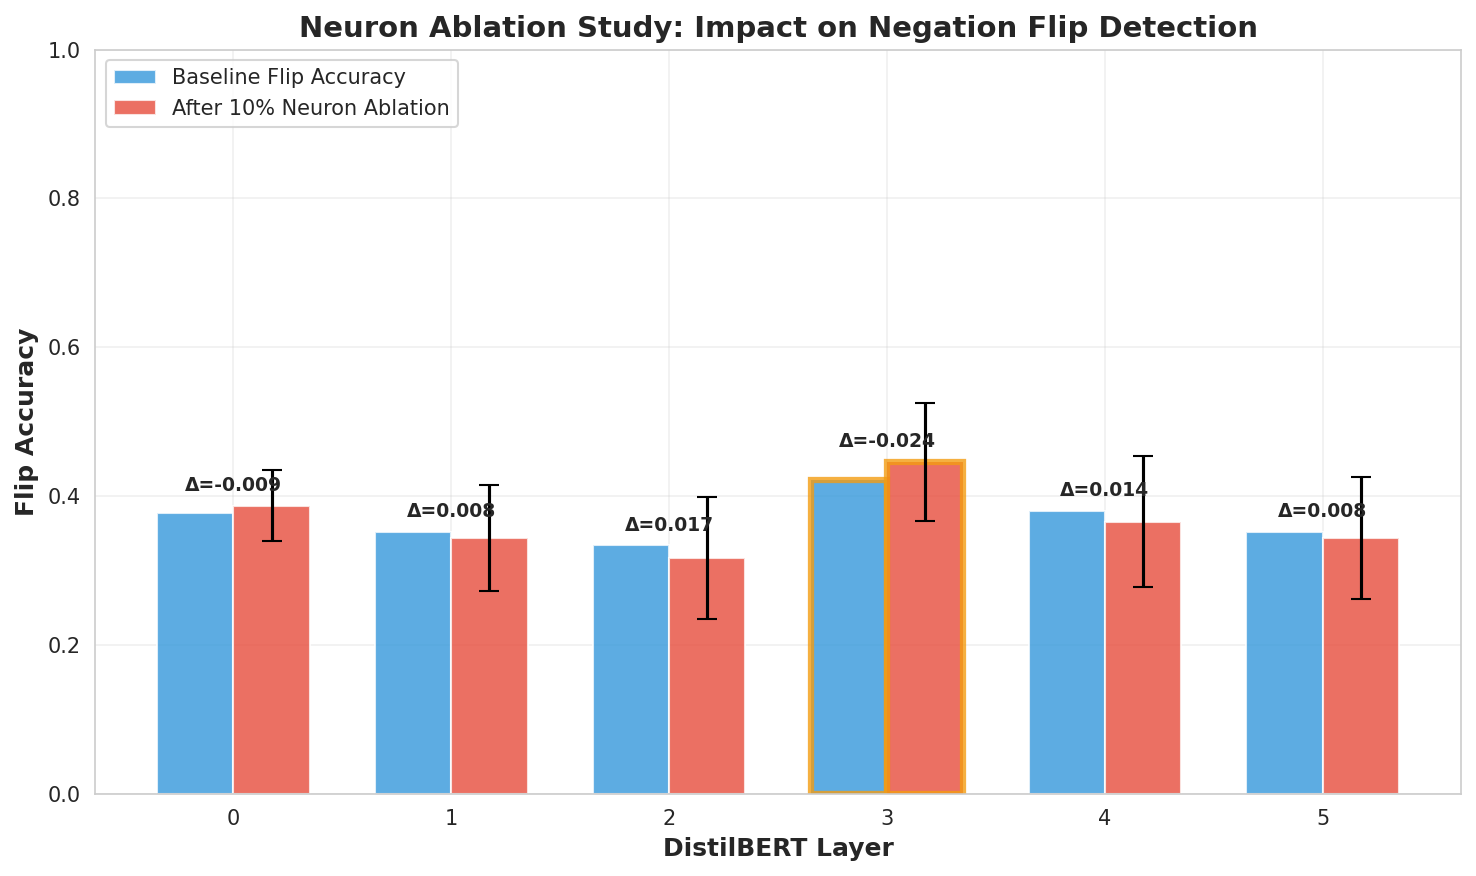

In [88]:
# Visualize ablation results
if ablation_results:
    fig, ax = plt.subplots(figsize=(10, 6))

    layers = [r['layer'] for r in ablation_results]
    baseline_accs = [r['baseline_flip_acc'] for r in ablation_results]
    ablated_accs = [r['ablated_flip_acc_mean'] for r in ablation_results]
    ablated_stds = [r['ablated_flip_acc_std'] for r in ablation_results]
    drops = [r['accuracy_drop'] for r in ablation_results]

    x = np.arange(len(layers))
    width = 0.35

    # Plot bars
    bars1 = ax.bar(x - width/2, baseline_accs, width, label='Baseline Flip Accuracy',
                   color=COLORS['anchor'], alpha=0.8)
    bars2 = ax.bar(x + width/2, ablated_accs, width, label='After 10% Neuron Ablation',
                   color=COLORS['negated'], alpha=0.8, yerr=ablated_stds, capsize=5)

    # Highlight Layer 3
    if 3 in layers:
        idx_3 = layers.index(3)
        bars1[idx_3].set_edgecolor(COLORS['layer3'])
        bars1[idx_3].set_linewidth(3)
        bars2[idx_3].set_edgecolor(COLORS['layer3'])
        bars2[idx_3].set_linewidth(3)

    # Add accuracy drop annotations
    for i, (layer, drop) in enumerate(zip(layers, drops)):
        ax.annotate(f'Δ={drop:.3f}', xy=(i, max(baseline_accs[i], ablated_accs[i]) + 0.02),
                   ha='center', fontsize=9, fontweight='bold')

    ax.set_xlabel('DistilBERT Layer', fontsize=12, fontweight='bold')
    ax.set_ylabel('Flip Accuracy', fontsize=12, fontweight='bold')
    ax.set_title('Neuron Ablation Study: Impact on Negation Flip Detection', fontsize=14, fontweight='bold')
    ax.set_xticks(x)
    ax.set_xticklabels(layers)
    ax.legend(loc='upper left')
    ax.set_ylim(0, 1.0)

    plt.tight_layout()

    save_path = os.path.join(OUTPUT_DIR, 'ablation_study.png')
    plt.savefig(save_path, dpi=300, bbox_inches='tight', facecolor='white')
    print(f"Saved: {save_path}")

    plt.show()
else:
    print("No ablation results to visualize. Check that probe checkpoints exist.")


## 6. Analysis 3: LDA-based Negation Direction

Use Linear Discriminant Analysis to find the direction in activation space that best separates anchors from negatives.

**Method:**
1. Fit LDA on Layer 3 representations (anchors vs negatives)
2. Project all sentences onto the discriminant direction
3. Visualize separation quality

**Expected Result:**
- Clear separation between anchor and negative projections at Layer 3


In [89]:
def compute_lda_separation(anchor_features, negative_features):
    """
    Compute LDA separation between anchors and negatives.

    Returns:
        dict with LDA model, projections, and separation metrics
    """
    # Prepare data
    X = torch.cat([anchor_features, negative_features], dim=0).numpy()
    y = np.array([0] * len(anchor_features) + [1] * len(negative_features))

    # Fit LDA
    lda = LinearDiscriminantAnalysis(n_components=1)
    X_lda = lda.fit_transform(X, y)

    # Compute separation metrics
    anchor_proj = X_lda[:len(anchor_features)].flatten()
    negative_proj = X_lda[len(anchor_features):].flatten()

    # Cohen's d effect size
    pooled_std = np.sqrt((np.var(anchor_proj) + np.var(negative_proj)) / 2)
    cohens_d = abs(np.mean(anchor_proj) - np.mean(negative_proj)) / pooled_std if pooled_std > 0 else 0

    # AUC for separation
    from sklearn.metrics import roc_auc_score
    auc = roc_auc_score(y, X_lda.flatten())
    if auc < 0.5:
        auc = 1 - auc  # Ensure AUC > 0.5

    return {
        'lda': lda,
        'anchor_projections': anchor_proj,
        'negative_projections': negative_proj,
        'cohens_d': cohens_d,
        'auc': auc,
        'explained_variance': lda.explained_variance_ratio_[0] if hasattr(lda, 'explained_variance_ratio_') else None,
    }

print("LDA separation function defined.")


LDA separation function defined.


In [90]:
# Compute LDA separation for all layers
print("Computing LDA separation for all layers...")

lda_results = []

for layer_idx in range(6):
    result = compute_lda_separation(
        distilbert_anchor_features[layer_idx],
        distilbert_negative_features[layer_idx]
    )
    result['layer'] = layer_idx
    lda_results.append(result)

    print(f"  Layer {layer_idx}: Cohen's d = {result['cohens_d']:.3f}, AUC = {result['auc']:.3f}")

# Find best layer
best_lda_layer = max(lda_results, key=lambda x: x['cohens_d'])['layer']
print(f"\n→ Best LDA separation at Layer {best_lda_layer}")


Computing LDA separation for all layers...
  Layer 0: Cohen's d = 8.774, AUC = 1.000
  Layer 1: Cohen's d = 9.301, AUC = 1.000
  Layer 2: Cohen's d = 9.719, AUC = 1.000
  Layer 3: Cohen's d = 9.876, AUC = 1.000
  Layer 4: Cohen's d = 9.752, AUC = 1.000
  Layer 5: Cohen's d = 10.848, AUC = 1.000

→ Best LDA separation at Layer 5


Saved: /content/drive/MyDrive/NOT_results/representation_analysis/lda_separation_all_layers.png


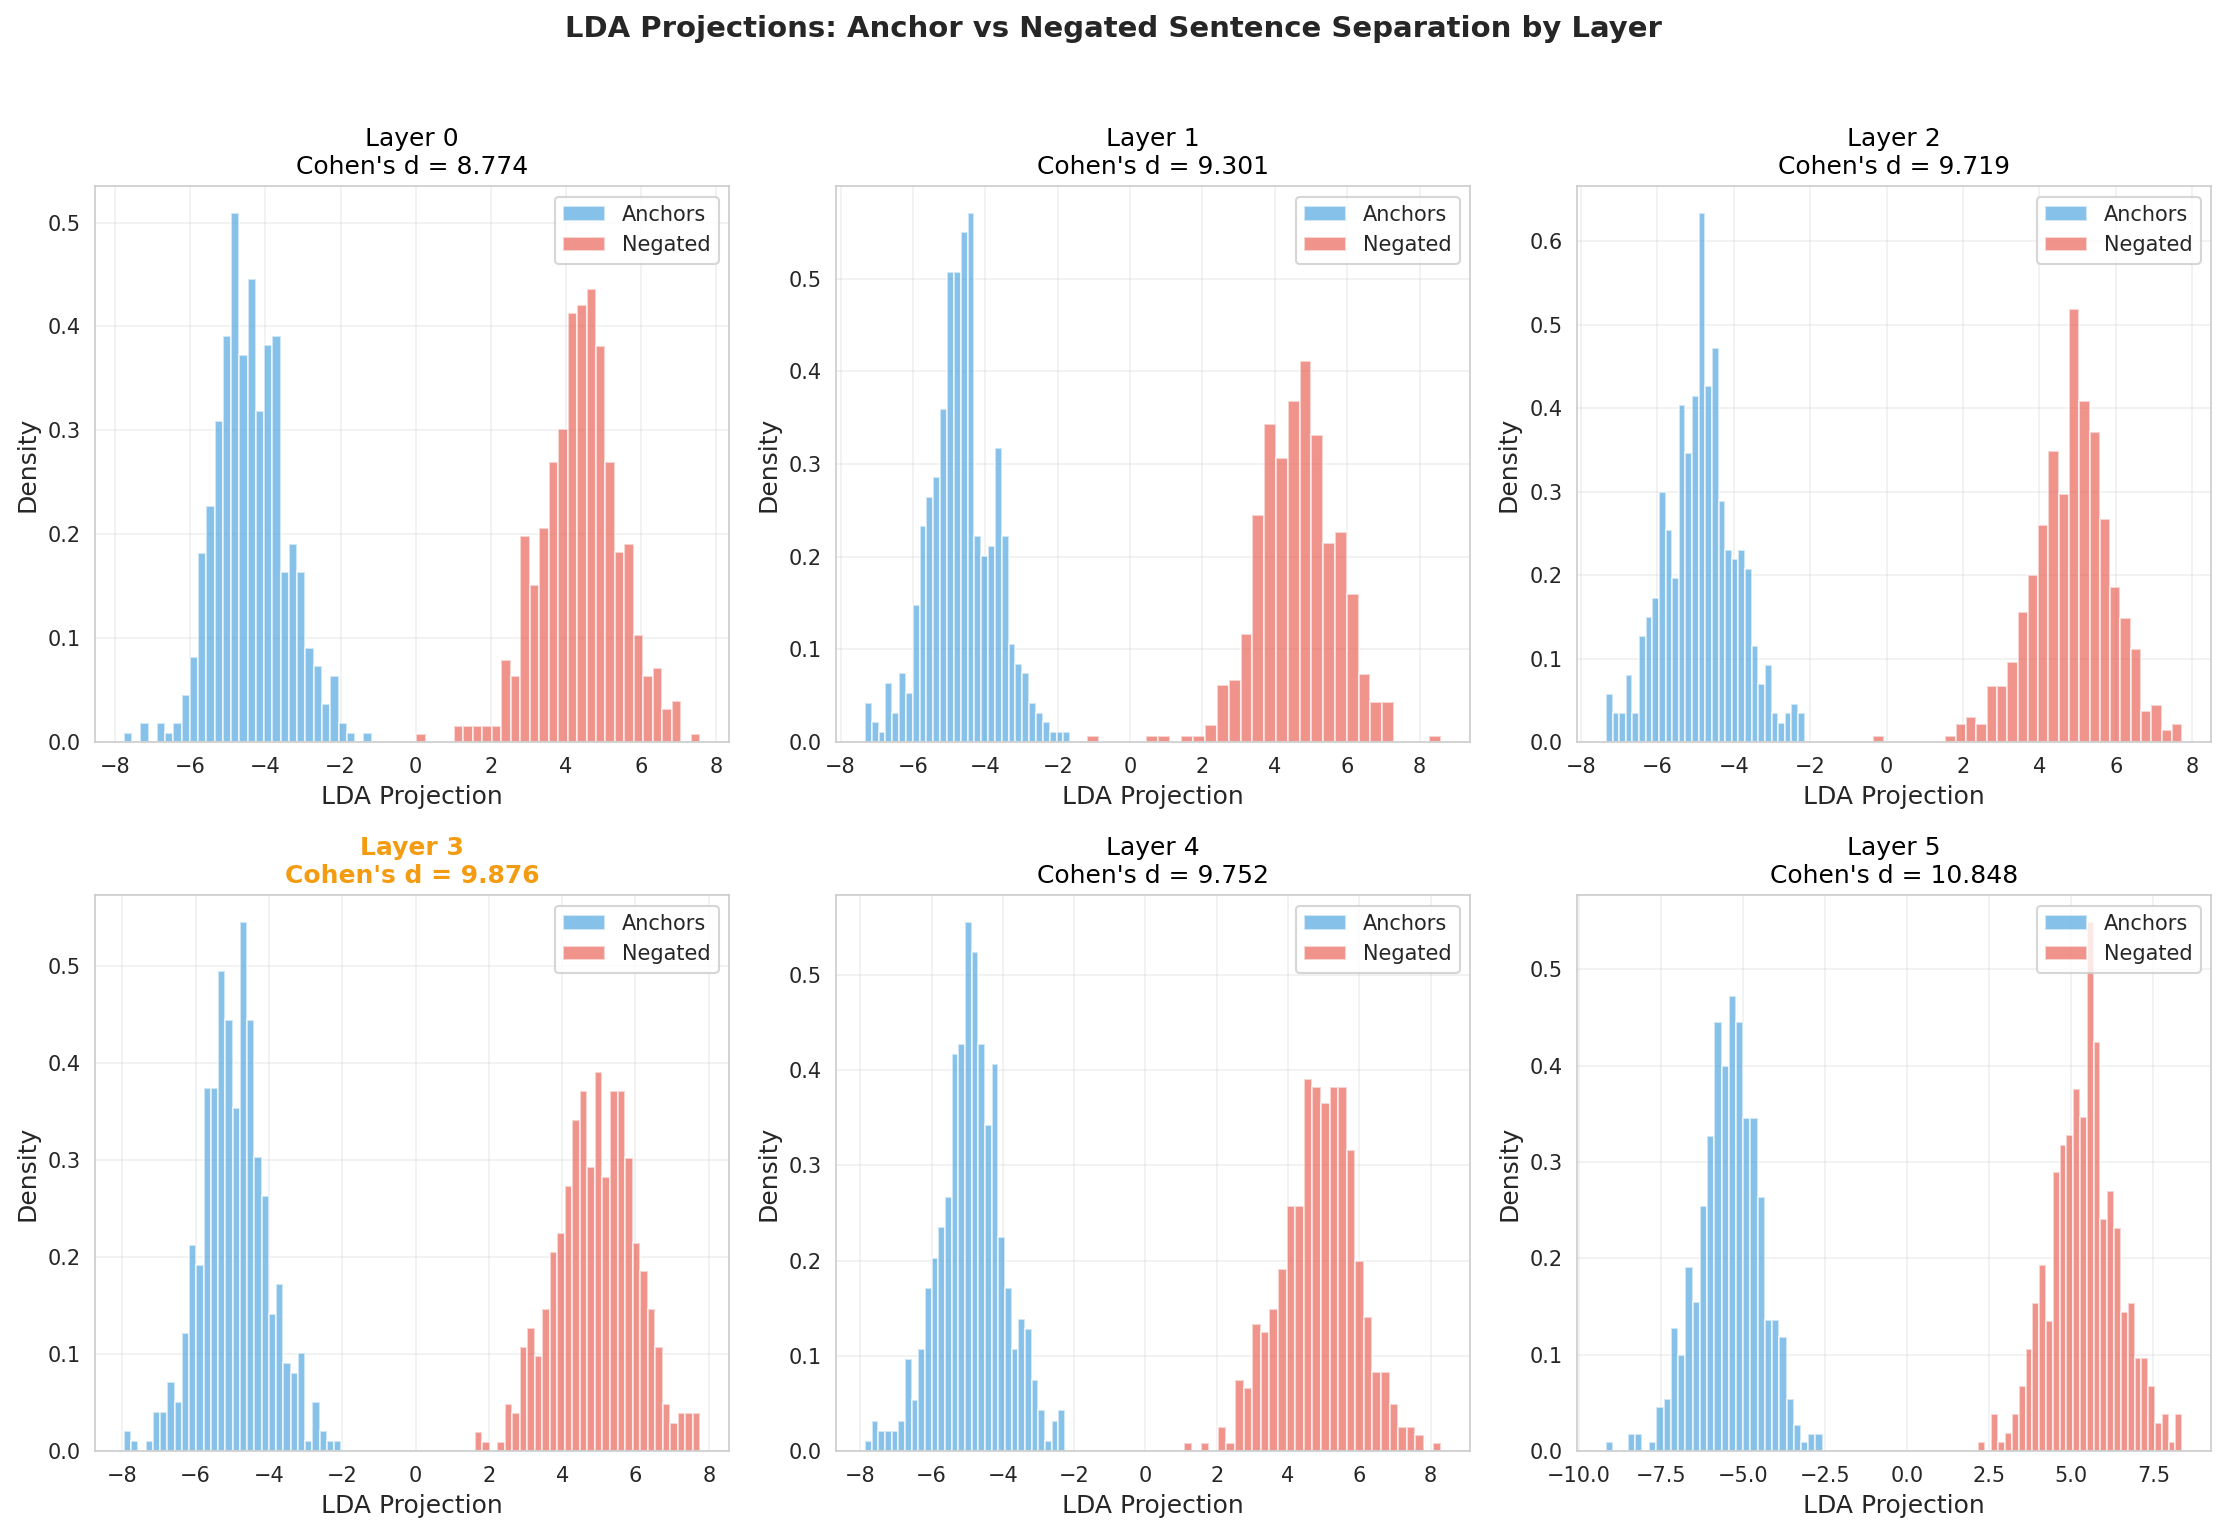

In [91]:
# Visualize LDA projections
fig, axes = plt.subplots(2, 3, figsize=(15, 10))

for idx, layer_idx in enumerate(range(6)):
    ax = axes[idx // 3, idx % 3]
    result = lda_results[layer_idx]

    # Plot histograms
    ax.hist(result['anchor_projections'], bins=30, alpha=0.6,
            color=COLORS['anchor'], label='Anchors', density=True)
    ax.hist(result['negative_projections'], bins=30, alpha=0.6,
            color=COLORS['negated'], label='Negated', density=True)

    # Highlight Layer 3
    title_color = COLORS['layer3'] if layer_idx == 3 else 'black'
    title_weight = 'bold' if layer_idx == 3 else 'normal'

    ax.set_title(f"Layer {layer_idx}\nCohen's d = {result['cohens_d']:.3f}",
                 fontsize=12, fontweight=title_weight, color=title_color)
    ax.set_xlabel('LDA Projection')
    ax.set_ylabel('Density')
    ax.legend(loc='upper right')

plt.suptitle('LDA Projections: Anchor vs Negated Sentence Separation by Layer',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()

save_path = os.path.join(OUTPUT_DIR, 'lda_separation_all_layers.png')
plt.savefig(save_path, dpi=300, bbox_inches='tight', facecolor='white')
print(f"Saved: {save_path}")

plt.show()


Saved: /content/drive/MyDrive/NOT_results/representation_analysis/lda_metrics_by_layer.png


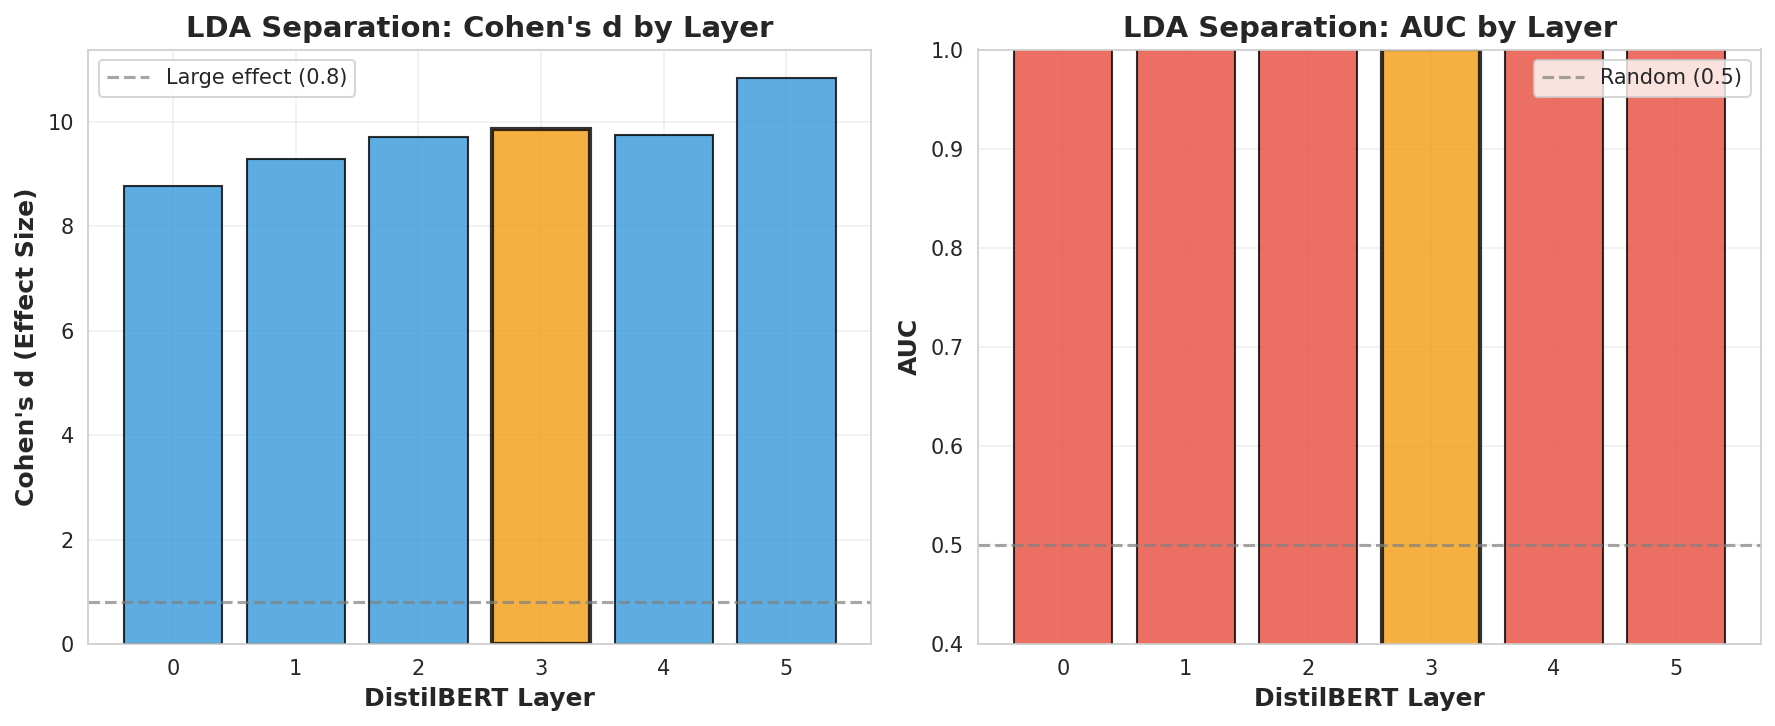

In [92]:
# Summary plot: LDA metrics by layer
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

layers = [r['layer'] for r in lda_results]
cohens_ds = [r['cohens_d'] for r in lda_results]
aucs = [r['auc'] for r in lda_results]

# Cohen's d
bars1 = ax1.bar(layers, cohens_ds, color=COLORS['anchor'], alpha=0.8, edgecolor='black')
bars1[3].set_color(COLORS['layer3'])
bars1[3].set_edgecolor('black')
bars1[3].set_linewidth(2)

ax1.set_xlabel('DistilBERT Layer', fontsize=12, fontweight='bold')
ax1.set_ylabel("Cohen's d (Effect Size)", fontsize=12, fontweight='bold')
ax1.set_title("LDA Separation: Cohen's d by Layer", fontsize=14, fontweight='bold')
ax1.axhline(y=0.8, color='gray', linestyle='--', alpha=0.7, label='Large effect (0.8)')
ax1.legend()

# AUC
bars2 = ax2.bar(layers, aucs, color=COLORS['negated'], alpha=0.8, edgecolor='black')
bars2[3].set_color(COLORS['layer3'])
bars2[3].set_edgecolor('black')
bars2[3].set_linewidth(2)

ax2.set_xlabel('DistilBERT Layer', fontsize=12, fontweight='bold')
ax2.set_ylabel('AUC', fontsize=12, fontweight='bold')
ax2.set_title('LDA Separation: AUC by Layer', fontsize=14, fontweight='bold')
ax2.axhline(y=0.5, color='gray', linestyle='--', alpha=0.7, label='Random (0.5)')
ax2.set_ylim(0.4, 1.0)
ax2.legend()

plt.tight_layout()

save_path = os.path.join(OUTPUT_DIR, 'lda_metrics_by_layer.png')
plt.savefig(save_path, dpi=300, bbox_inches='tight', facecolor='white')
print(f"Saved: {save_path}")

plt.show()


## 7. Analysis 4: Cross-Model Canonical Correlation Analysis (CCA)

This analysis tests the distillation hypothesis directly by measuring representational alignment between BERT and DistilBERT layers.

**Hypothesis:**
- DistilBERT Layer 3 should have highest correlation with BERT Layers 7/9
- This shows knowledge was transferred, not just that Layer 3 is independently good

**Method:**
- Compute CCA between each BERT layer and each DistilBERT layer
- Create correlation matrix showing alignment strength


In [93]:
def compute_svcca_correlation(features_a, features_b, n_components=20, variance_threshold=0.99, top_k=10):
    """
    Compute SVCCA (Singular Vector CCA) correlation between two sets of features.

    This implements the SVCCA method from Raghu et al. 2017 "SVCCA: Singular Vector
    Canonical Correlation Analysis for Deep Learning Dynamics and Interpretability"

    Key improvements over naive CCA:
    1. Uses SVD for dimensionality reduction (more stable than PCA for this use case)
    2. Only centers data, no per-layer normalization (preserves scale information)
    3. Uses variance threshold to select meaningful dimensions
    4. Reports mean of top-k correlations for robustness
    5. Adds regularization via truncated SVD

    Args:
        features_a: Tensor of shape (N, hidden_size_a) - e.g., BERT layer activations
        features_b: Tensor of shape (N, hidden_size_b) - e.g., DistilBERT layer activations
        n_components: Maximum number of CCA components to compute
        variance_threshold: Keep SVD components explaining this much variance (0.99 = 99%)
        top_k: Number of top canonical correlations to average

    Returns:
        Mean of top-k canonical correlations (float between 0 and 1)
    """
    from sklearn.decomposition import TruncatedSVD
    from scipy import linalg

    # Convert to numpy, handling GPU tensors and gradients
    if isinstance(features_a, torch.Tensor):
        features_a = features_a.detach()
        if features_a.is_cuda:
            features_a = features_a.cpu()
        X = features_a.numpy()
    else:
        X = np.array(features_a)

    if isinstance(features_b, torch.Tensor):
        features_b = features_b.detach()
        if features_b.is_cuda:
            features_b = features_b.cpu()
        Y = features_b.numpy()
    else:
        Y = np.array(features_b)

    # Ensure 2D arrays
    if X.ndim != 2:
        X = X.reshape(-1, X.shape[-1]) if X.ndim > 2 else X.reshape(-1, 1)
    if Y.ndim != 2:
        Y = Y.reshape(-1, Y.shape[-1]) if Y.ndim > 2 else Y.reshape(-1, 1)

    # Ensure same number of samples
    n_samples = min(X.shape[0], Y.shape[0])
    if n_samples < 10:  # Need minimum samples for meaningful CCA
        return 0.0

    X = X[:n_samples]
    Y = Y[:n_samples]

    # Handle NaN/inf values
    X = np.nan_to_num(X, nan=0.0, posinf=0.0, neginf=0.0)
    Y = np.nan_to_num(Y, nan=0.0, posinf=0.0, neginf=0.0)

    # Step 1: Center the data (subtract mean) - NO normalization/scaling
    # This preserves the relative scale of activations across layers
    X_centered = X - np.mean(X, axis=0, keepdims=True)
    Y_centered = Y - np.mean(Y, axis=0, keepdims=True)

    # Step 2: Apply truncated SVD to reduce dimensionality
    # This is more stable than PCA and handles the high-dimensional case better
    # Use variance threshold to determine number of components

    def get_svd_components(data, var_threshold=0.99, max_components=None):
        """Get SVD components that explain var_threshold of variance."""
        # Compute full SVD to determine variance explained
        try:
            U, s, Vt = linalg.svd(data, full_matrices=False)
        except linalg.LinAlgError:
            # Fall back to randomized SVD if full SVD fails
            max_k = min(data.shape) - 1
            if max_k < 1:
                return data
            svd = TruncatedSVD(n_components=max_k)
            return svd.fit_transform(data)

        # Calculate cumulative variance explained
        var_explained = np.cumsum(s**2) / np.sum(s**2)

        # Find number of components for threshold
        n_keep = np.searchsorted(var_explained, var_threshold) + 1

        # Also limit by max_components if specified
        if max_components is not None:
            n_keep = min(n_keep, max_components)

        # Ensure we keep at least 1 and at most rank components
        n_keep = max(1, min(n_keep, len(s), n_samples - 1))

        # Return projected data
        return U[:, :n_keep] * s[:n_keep]

    # Determine max components based on sample size
    max_svd_components = min(n_samples // 2, 100)  # Conservative limit

    try:
        X_reduced = get_svd_components(X_centered, variance_threshold, max_svd_components)
        Y_reduced = get_svd_components(Y_centered, variance_threshold, max_svd_components)
    except Exception as e:
        print(f"SVD failed: {e}")
        return 0.0

    # Step 3: Compute CCA on reduced representations
    n_cca_components = min(n_components, X_reduced.shape[1], Y_reduced.shape[1], n_samples - 1)

    if n_cca_components < 1:
        return 0.0

    try:
        # Use scipy's canonical correlation computation for better numerical stability
        # Compute cross-covariance matrix
        C_xy = np.dot(X_reduced.T, Y_reduced) / (n_samples - 1)
        C_xx = np.dot(X_reduced.T, X_reduced) / (n_samples - 1)
        C_yy = np.dot(Y_reduced.T, Y_reduced) / (n_samples - 1)

        # Add small regularization for numerical stability
        reg = 1e-4
        C_xx += reg * np.eye(C_xx.shape[0])
        C_yy += reg * np.eye(C_yy.shape[0])

        # Compute canonical correlations via generalized eigenvalue problem
        # This is equivalent to CCA but more numerically stable
        try:
            # Cholesky decomposition for whitening
            L_x = linalg.cholesky(C_xx, lower=True)
            L_y = linalg.cholesky(C_yy, lower=True)

            # Whitened cross-covariance
            L_x_inv = linalg.solve_triangular(L_x, np.eye(L_x.shape[0]), lower=True)
            L_y_inv = linalg.solve_triangular(L_y, np.eye(L_y.shape[0]), lower=True)

            M = np.dot(np.dot(L_x_inv, C_xy), L_y_inv.T)

            # SVD of M gives canonical correlations
            U, s, Vt = linalg.svd(M, full_matrices=False)

            # Canonical correlations are the singular values, clipped to [0, 1]
            correlations = np.clip(s, 0.0, 1.0)

        except linalg.LinAlgError:
            # Fall back to sklearn CCA if Cholesky fails
            from sklearn.cross_decomposition import CCA
            cca = CCA(n_components=n_cca_components, max_iter=1000)
            X_c, Y_c = cca.fit_transform(X_reduced, Y_reduced)

            # Compute correlations manually
            correlations = []
            for i in range(X_c.shape[1]):
                x_comp = X_c[:, i]
                y_comp = Y_c[:, i]

                x_std = np.std(x_comp)
                y_std = np.std(y_comp)

                if x_std < 1e-10 or y_std < 1e-10:
                    continue

                corr = np.corrcoef(x_comp, y_comp)[0, 1]
                if not np.isnan(corr):
                    correlations.append(abs(corr))

            correlations = np.array(correlations) if correlations else np.array([0.0])

        # Step 4: Return mean of top-k correlations
        if len(correlations) == 0:
            return 0.0

        # Sort in descending order and take top-k
        correlations_sorted = np.sort(correlations)[::-1]
        k = min(top_k, len(correlations_sorted))
        mean_top_k = np.mean(correlations_sorted[:k])

        return float(mean_top_k)

    except Exception as e:
        print(f"CCA computation failed: {e}")
        return 0.0


def compute_cka(features_a, features_b, kernel='linear'):
    """
    Compute CKA (Centered Kernel Alignment) between two sets of features.

    CKA is a similarity measure for neural network representations that is:
    - Invariant to orthogonal transformations and isotropic scaling
    - More robust than CCA when representations saturate
    - Based on kernel methods (HSIC - Hilbert-Schmidt Independence Criterion)

    Reference: Kornblith et al. 2019 "Similarity of Neural Network Representations Revisited"

    Args:
        features_a: Tensor of shape (N, hidden_size_a)
        features_b: Tensor of shape (N, hidden_size_b)
        kernel: 'linear' or 'rbf' (radial basis function)

    Returns:
        CKA similarity score (float between 0 and 1)
    """
    # Convert to numpy
    if isinstance(features_a, torch.Tensor):
        features_a = features_a.detach()
        if features_a.is_cuda:
            features_a = features_a.cpu()
        X = features_a.numpy()
    else:
        X = np.array(features_a)

    if isinstance(features_b, torch.Tensor):
        features_b = features_b.detach()
        if features_b.is_cuda:
            features_b = features_b.cpu()
        Y = features_b.numpy()
    else:
        Y = np.array(features_b)

    # Ensure 2D
    if X.ndim != 2:
        X = X.reshape(-1, X.shape[-1]) if X.ndim > 2 else X.reshape(-1, 1)
    if Y.ndim != 2:
        Y = Y.reshape(-1, Y.shape[-1]) if Y.ndim > 2 else Y.reshape(-1, 1)

    # Ensure same samples
    n_samples = min(X.shape[0], Y.shape[0])
    if n_samples < 2:
        return 0.0

    X = X[:n_samples]
    Y = Y[:n_samples]

    # Handle NaN/inf
    X = np.nan_to_num(X, nan=0.0, posinf=0.0, neginf=0.0)
    Y = np.nan_to_num(Y, nan=0.0, posinf=0.0, neginf=0.0)

    def centering_matrix(n):
        """Create centering matrix H = I - (1/n) * 1 * 1^T"""
        return np.eye(n) - np.ones((n, n)) / n

    def compute_gram_matrix(features, kernel_type='linear'):
        """Compute Gram matrix (kernel matrix)"""
        if kernel_type == 'linear':
            return np.dot(features, features.T)
        elif kernel_type == 'rbf':
            # RBF kernel with median heuristic for bandwidth
            from scipy.spatial.distance import pdist, squareform
            dists = squareform(pdist(features, 'sqeuclidean'))
            sigma = np.median(dists[dists > 0]) if np.any(dists > 0) else 1.0
            return np.exp(-dists / (2 * sigma))
        else:
            raise ValueError(f"Unknown kernel: {kernel_type}")

    def hsic(K, L, H):
        """Compute HSIC (Hilbert-Schmidt Independence Criterion)"""
        # HSIC = (1/(n-1)^2) * trace(KHLH)
        n = K.shape[0]
        KH = np.dot(K, H)
        LH = np.dot(L, H)
        return np.trace(np.dot(KH, LH)) / ((n - 1) ** 2)

    try:
        # Compute Gram matrices
        K = compute_gram_matrix(X, kernel)
        L = compute_gram_matrix(Y, kernel)

        # Centering matrix
        H = centering_matrix(n_samples)

        # Compute CKA = HSIC(K, L) / sqrt(HSIC(K, K) * HSIC(L, L))
        hsic_kl = hsic(K, L, H)
        hsic_kk = hsic(K, K, H)
        hsic_ll = hsic(L, L, H)

        denominator = np.sqrt(hsic_kk * hsic_ll)

        if denominator < 1e-10:
            return 0.0

        cka = hsic_kl / denominator

        # Clamp to [0, 1]
        return float(np.clip(cka, 0.0, 1.0))

    except Exception as e:
        print(f"CKA computation failed: {e}")
        return 0.0


def compute_pwcca(features_a, features_b, n_components=20, variance_threshold=0.99):
    """
    Compute PWCCA (Projection Weighted CCA) between two sets of features.

    PWCCA weights canonical correlations by the importance of each direction
    in the original representation space, making it more robust than mean CCA.

    Reference: Morcos et al. 2018 "Insights on representational similarity..."

    Args:
        features_a: Tensor of shape (N, hidden_size_a)
        features_b: Tensor of shape (N, hidden_size_b)
        n_components: Maximum number of CCA components
        variance_threshold: Keep SVD components explaining this much variance

    Returns:
        PWCCA similarity score (float between 0 and 1)
    """
    from scipy import linalg

    # Convert to numpy
    if isinstance(features_a, torch.Tensor):
        features_a = features_a.detach()
        if features_a.is_cuda:
            features_a = features_a.cpu()
        X = features_a.numpy()
    else:
        X = np.array(features_a)

    if isinstance(features_b, torch.Tensor):
        features_b = features_b.detach()
        if features_b.is_cuda:
            features_b = features_b.cpu()
        Y = features_b.numpy()
    else:
        Y = np.array(features_b)

    # Ensure 2D
    if X.ndim != 2:
        X = X.reshape(-1, X.shape[-1]) if X.ndim > 2 else X.reshape(-1, 1)
    if Y.ndim != 2:
        Y = Y.reshape(-1, Y.shape[-1]) if Y.ndim > 2 else Y.reshape(-1, 1)

    # Ensure same samples
    n_samples = min(X.shape[0], Y.shape[0])
    if n_samples < 10:
        return 0.0

    X = X[:n_samples]
    Y = Y[:n_samples]

    # Handle NaN/inf
    X = np.nan_to_num(X, nan=0.0, posinf=0.0, neginf=0.0)
    Y = np.nan_to_num(Y, nan=0.0, posinf=0.0, neginf=0.0)

    # Center the data
    X_centered = X - np.mean(X, axis=0, keepdims=True)
    Y_centered = Y - np.mean(Y, axis=0, keepdims=True)

    try:
        # SVD for dimensionality reduction
        U_x, s_x, Vt_x = linalg.svd(X_centered, full_matrices=False)
        U_y, s_y, Vt_y = linalg.svd(Y_centered, full_matrices=False)

        # Determine components to keep based on variance
        var_x = np.cumsum(s_x**2) / np.sum(s_x**2)
        var_y = np.cumsum(s_y**2) / np.sum(s_y**2)

        n_x = min(np.searchsorted(var_x, variance_threshold) + 1, len(s_x), n_samples // 2)
        n_y = min(np.searchsorted(var_y, variance_threshold) + 1, len(s_y), n_samples // 2)
        n_x = max(1, n_x)
        n_y = max(1, n_y)

        # Reduced representations
        X_reduced = U_x[:, :n_x] * s_x[:n_x]
        Y_reduced = U_y[:, :n_y] * s_y[:n_y]

        # CCA on reduced representations
        n_cca = min(n_components, n_x, n_y, n_samples - 1)

        if n_cca < 1:
            return 0.0

        # Compute covariance matrices
        C_xy = np.dot(X_reduced.T, Y_reduced) / (n_samples - 1)
        C_xx = np.dot(X_reduced.T, X_reduced) / (n_samples - 1)
        C_yy = np.dot(Y_reduced.T, Y_reduced) / (n_samples - 1)

        # Regularization
        reg = 1e-4
        C_xx += reg * np.eye(C_xx.shape[0])
        C_yy += reg * np.eye(C_yy.shape[0])

        # Cholesky whitening
        L_x = linalg.cholesky(C_xx, lower=True)
        L_y = linalg.cholesky(C_yy, lower=True)

        L_x_inv = linalg.solve_triangular(L_x, np.eye(L_x.shape[0]), lower=True)
        L_y_inv = linalg.solve_triangular(L_y, np.eye(L_y.shape[0]), lower=True)

        M = np.dot(np.dot(L_x_inv, C_xy), L_y_inv.T)

        # SVD gives canonical correlations and directions
        U, correlations, Vt = linalg.svd(M, full_matrices=False)
        correlations = np.clip(correlations, 0.0, 1.0)

        # Compute projection weights (how much variance each CCA direction explains)
        # Weight by singular values of original data projected onto CCA directions
        cca_directions_x = np.dot(L_x_inv.T, U)

        # Project original data onto CCA directions
        X_proj = np.dot(X_reduced, cca_directions_x)

        # Weights are the variance explained by each direction
        weights = np.var(X_proj, axis=0)
        weights = weights / (np.sum(weights) + 1e-10)

        # PWCCA is weighted mean of correlations
        pwcca = np.sum(weights[:len(correlations)] * correlations)

        return float(np.clip(pwcca, 0.0, 1.0))

    except Exception as e:
        # Fall back to SVCCA if PWCCA fails
        return compute_svcca_correlation(features_a, features_b, n_components, variance_threshold)


# Backward compatibility wrapper
def compute_cca_correlation(features_a, features_b, n_components=10):
    """Wrapper for backward compatibility - uses improved SVCCA."""
    return compute_svcca_correlation(features_a, features_b, n_components=n_components)


print("Representation similarity functions defined:")
print("  1. SVCCA (Singular Vector CCA) - SVD preprocessing + regularization")
print("  2. PWCCA (Projection Weighted CCA) - Variance-weighted correlations")
print("  3. CKA (Centered Kernel Alignment) - Kernel-based, robust to saturation")
print("\nRecommendation: Use CKA when SVCCA/PWCCA saturate at ~1.0")


Representation similarity functions defined:
  1. SVCCA (Singular Vector CCA) - SVD preprocessing + regularization
  2. PWCCA (Projection Weighted CCA) - Variance-weighted correlations
  3. CKA (Centered Kernel Alignment) - Kernel-based, robust to saturation

Recommendation: Use CKA when SVCCA/PWCCA saturate at ~1.0


In [94]:
# Compute representation similarity matrices between BERT and DistilBERT layers
# Using multiple methods: SVCCA, PWCCA, and CKA for robustness

print("=" * 70)
print("COMPUTING REPRESENTATION SIMILARITY: SVCCA, PWCCA, AND CKA")
print("=" * 70)

# Combine anchor and negative features for more data
distilbert_all_features = {
    layer: torch.cat([distilbert_anchor_features[layer], distilbert_negative_features[layer]], dim=0)
    for layer in range(6)
}
bert_all_features = {
    layer: torch.cat([bert_anchor_features[layer], bert_negative_features[layer]], dim=0)
    for layer in range(12)
}

# Print sample sizes
n_samples_cca = distilbert_all_features[0].shape[0]
print(f"\nUsing {n_samples_cca} samples (anchor + negative pairs)")
print(f"BERT hidden size: {bert_all_features[0].shape[1]}")
print(f"DistilBERT hidden size: {distilbert_all_features[0].shape[1]}")

print("\nMethods being computed:")
print("  1. SVCCA - Singular Vector CCA (Raghu et al. 2017)")
print("  2. PWCCA - Projection Weighted CCA (Morcos et al. 2018)")
print("  3. CKA   - Centered Kernel Alignment (Kornblith et al. 2019)")
print("\nComputing all three metrics (this may take a few minutes)...\n")

# Initialize matrices for all three methods
svcca_matrix = np.zeros((12, 6))  # BERT layers x DistilBERT layers
pwcca_matrix = np.zeros((12, 6))
cka_matrix = np.zeros((12, 6))

for bert_layer in tqdm(range(12), desc="BERT layers"):
    for distil_layer in range(6):
        bert_feats = bert_all_features[bert_layer]
        distil_feats = distilbert_all_features[distil_layer]

        # SVCCA
        svcca_matrix[bert_layer, distil_layer] = compute_svcca_correlation(
            bert_feats, distil_feats,
            n_components=20, variance_threshold=0.99, top_k=10
        )

        # PWCCA
        pwcca_matrix[bert_layer, distil_layer] = compute_pwcca(
            bert_feats, distil_feats,
            n_components=20, variance_threshold=0.99
        )

        # CKA (linear kernel)
        cka_matrix[bert_layer, distil_layer] = compute_cka(
            bert_feats, distil_feats, kernel='linear'
        )

# Use CKA as the primary metric (most robust when CCA saturates)
# Keep cca_matrix as alias for backward compatibility
cca_matrix = cka_matrix.copy()

print("\n" + "=" * 70)
print("REPRESENTATION SIMILARITY MATRICES COMPUTED")
print("=" * 70)

# Print summary statistics for each method
print("\n" + "-" * 50)
print("SVCCA (Singular Vector CCA):")
print(f"  Range: [{svcca_matrix.min():.3f}, {svcca_matrix.max():.3f}]")
print(f"  Mean:  {svcca_matrix.mean():.3f}")
if svcca_matrix.max() > 0.99:
    print("  ⚠️  Saturating at ~1.0 (CKA may show clearer structure)")

print("\n" + "-" * 50)
print("PWCCA (Projection Weighted CCA):")
print(f"  Range: [{pwcca_matrix.min():.3f}, {pwcca_matrix.max():.3f}]")
print(f"  Mean:  {pwcca_matrix.mean():.3f}")

print("\n" + "-" * 50)
print("CKA (Centered Kernel Alignment) - PRIMARY METRIC:")
print(f"  Range: [{cka_matrix.min():.3f}, {cka_matrix.max():.3f}]")
print(f"  Mean:  {cka_matrix.mean():.3f}")

# Determine which metric shows the most structure
svcca_range = svcca_matrix.max() - svcca_matrix.min()
pwcca_range = pwcca_matrix.max() - pwcca_matrix.min()
cka_range = cka_matrix.max() - cka_matrix.min()

print("\n" + "-" * 50)
print("METRIC COMPARISON (larger range = more discriminative):")
print(f"  SVCCA range: {svcca_range:.3f}")
print(f"  PWCCA range: {pwcca_range:.3f}")
print(f"  CKA range:   {cka_range:.3f}")

best_metric = max([('SVCCA', svcca_range), ('PWCCA', pwcca_range), ('CKA', cka_range)], key=lambda x: x[1])
print(f"\n✓ {best_metric[0]} shows the most discriminative structure")

# If CKA shows more structure, recommend using it
if cka_range > svcca_range:
    print("\n📊 Using CKA for visualization (shows clearer layer alignment)")
else:
    print("\n📊 SVCCA shows good structure, using for visualization")
    cca_matrix = svcca_matrix.copy()


COMPUTING REPRESENTATION SIMILARITY: SVCCA, PWCCA, AND CKA

Using 1000 samples (anchor + negative pairs)
BERT hidden size: 768
DistilBERT hidden size: 768

Methods being computed:
  1. SVCCA - Singular Vector CCA (Raghu et al. 2017)
  2. PWCCA - Projection Weighted CCA (Morcos et al. 2018)
  3. CKA   - Centered Kernel Alignment (Kornblith et al. 2019)

Computing all three metrics (this may take a few minutes)...



BERT layers:   0%|          | 0/12 [00:00<?, ?it/s]


REPRESENTATION SIMILARITY MATRICES COMPUTED

--------------------------------------------------
SVCCA (Singular Vector CCA):
  Range: [0.957, 0.997]
  Mean:  0.982
  ⚠️  Saturating at ~1.0 (CKA may show clearer structure)

--------------------------------------------------
PWCCA (Projection Weighted CCA):
  Range: [0.699, 0.894]
  Mean:  0.796

--------------------------------------------------
CKA (Centered Kernel Alignment) - PRIMARY METRIC:
  Range: [0.682, 0.972]
  Mean:  0.857

--------------------------------------------------
METRIC COMPARISON (larger range = more discriminative):
  SVCCA range: 0.040
  PWCCA range: 0.195
  CKA range:   0.290

✓ CKA shows the most discriminative structure

📊 Using CKA for visualization (shows clearer layer alignment)


Saved: /content/drive/MyDrive/NOT_results/representation_analysis/representation_similarity_comparison.png


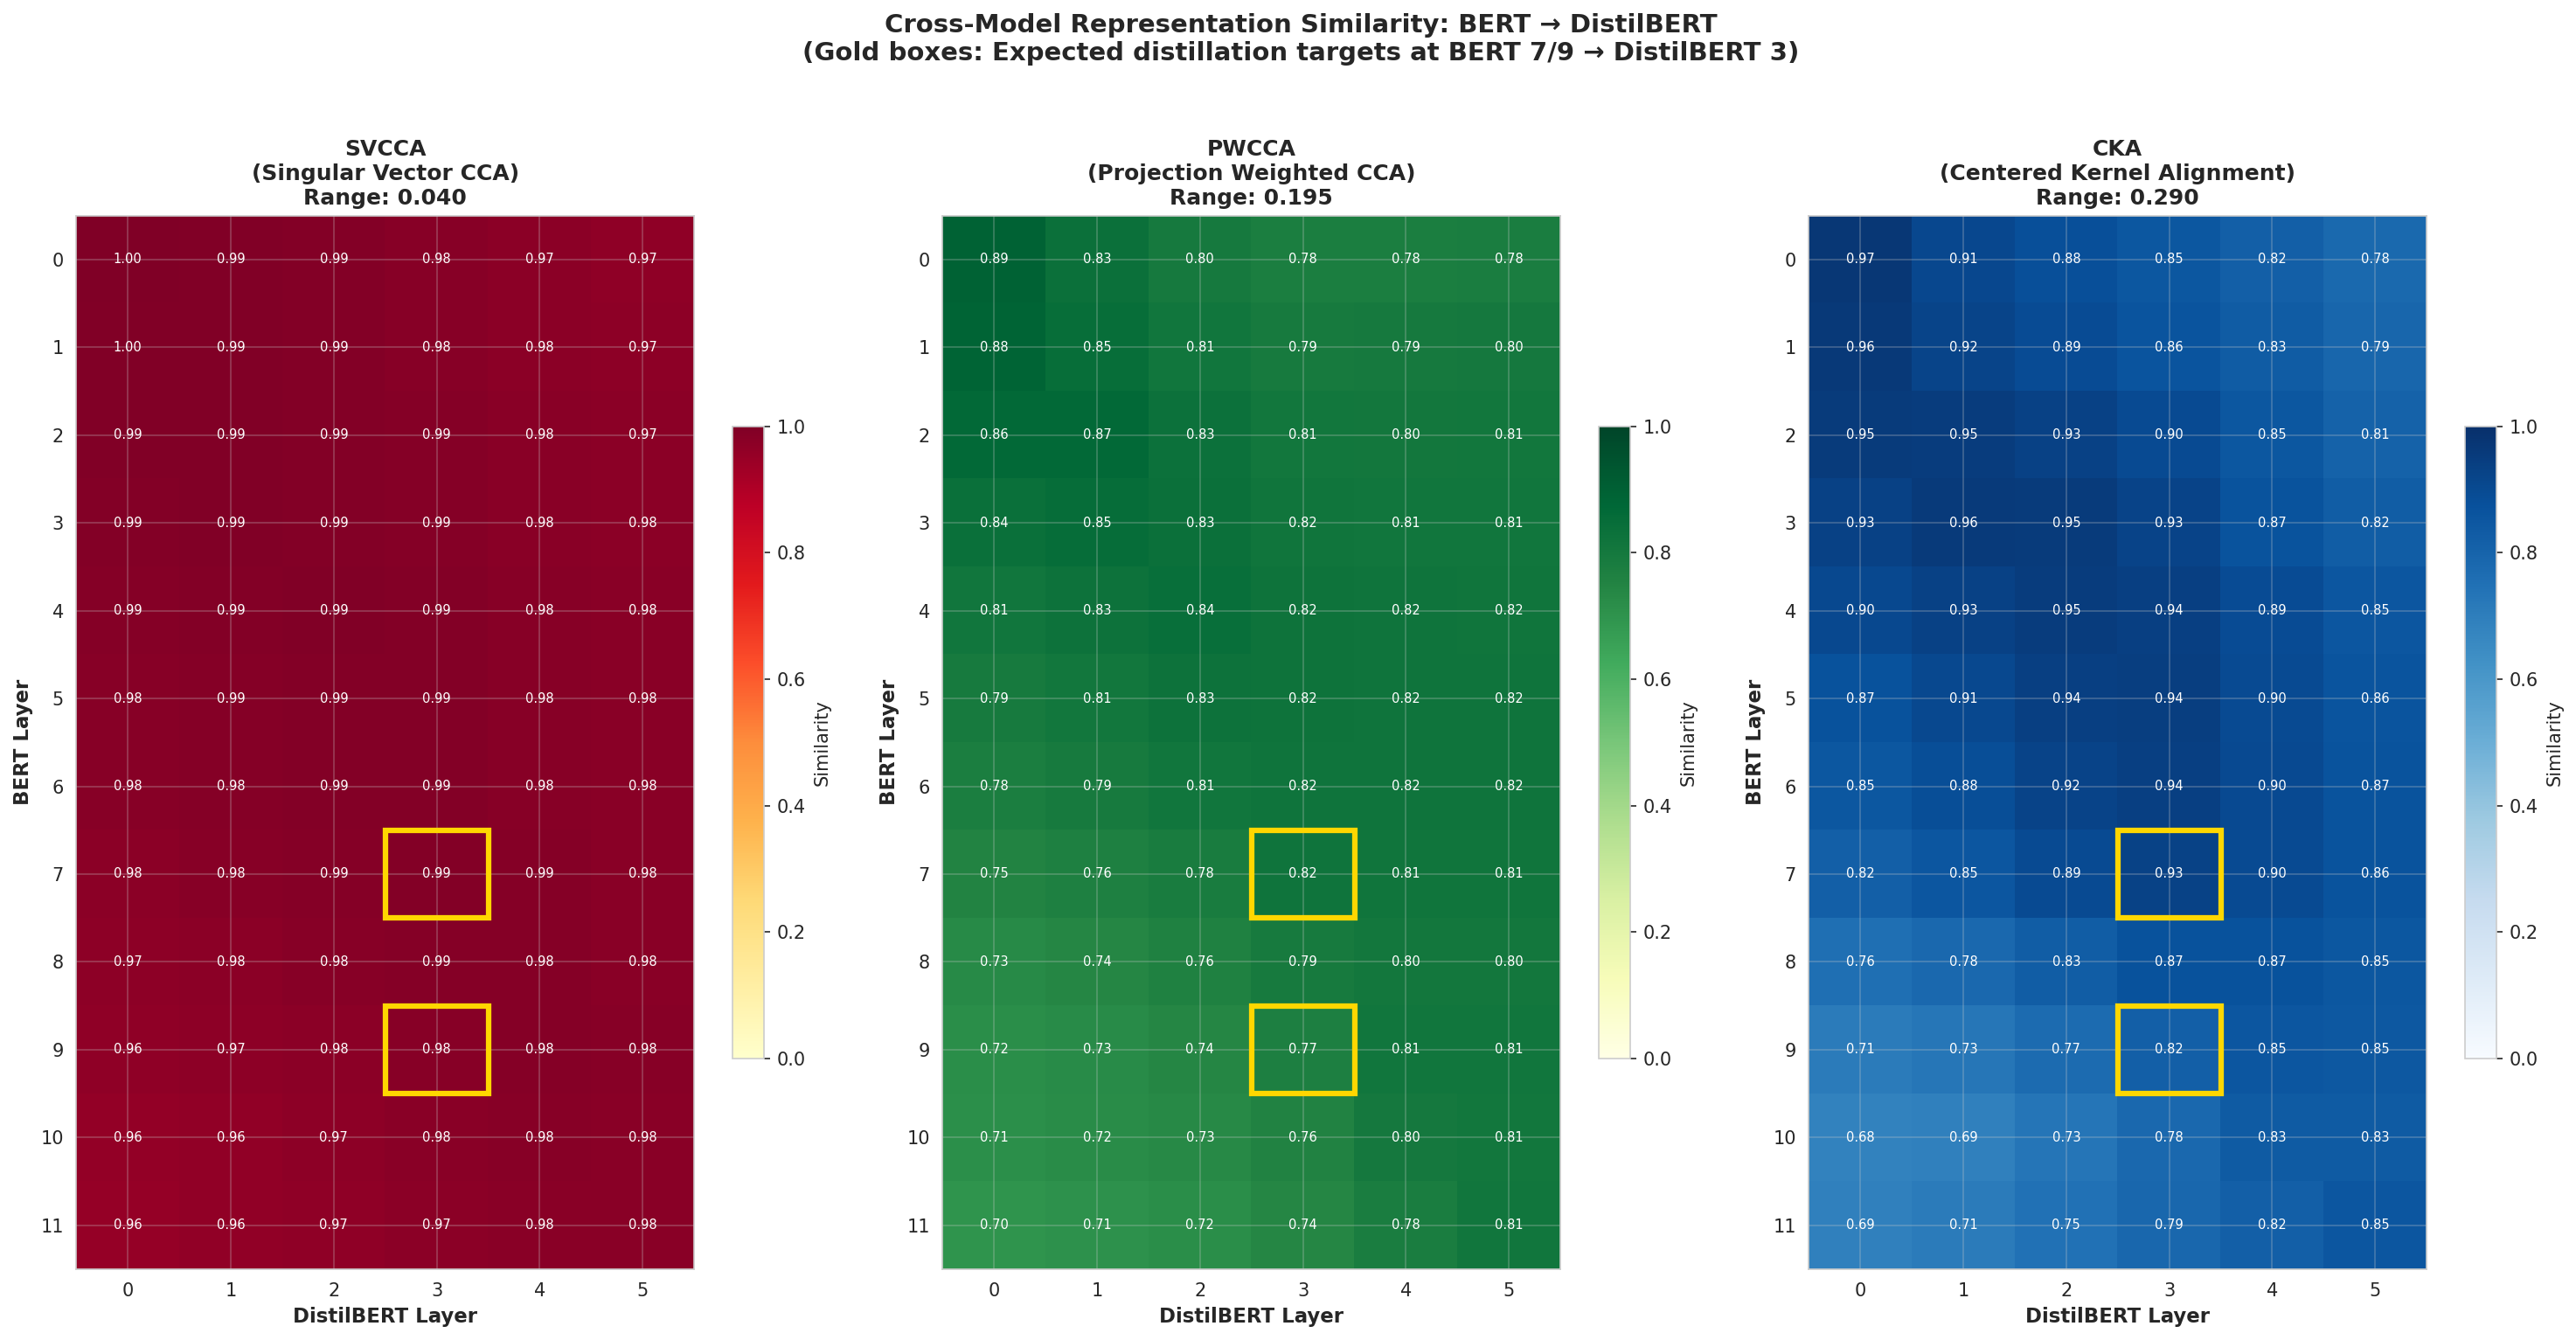

Saved: /content/drive/MyDrive/NOT_results/representation_analysis/cka_correlation_matrix.png


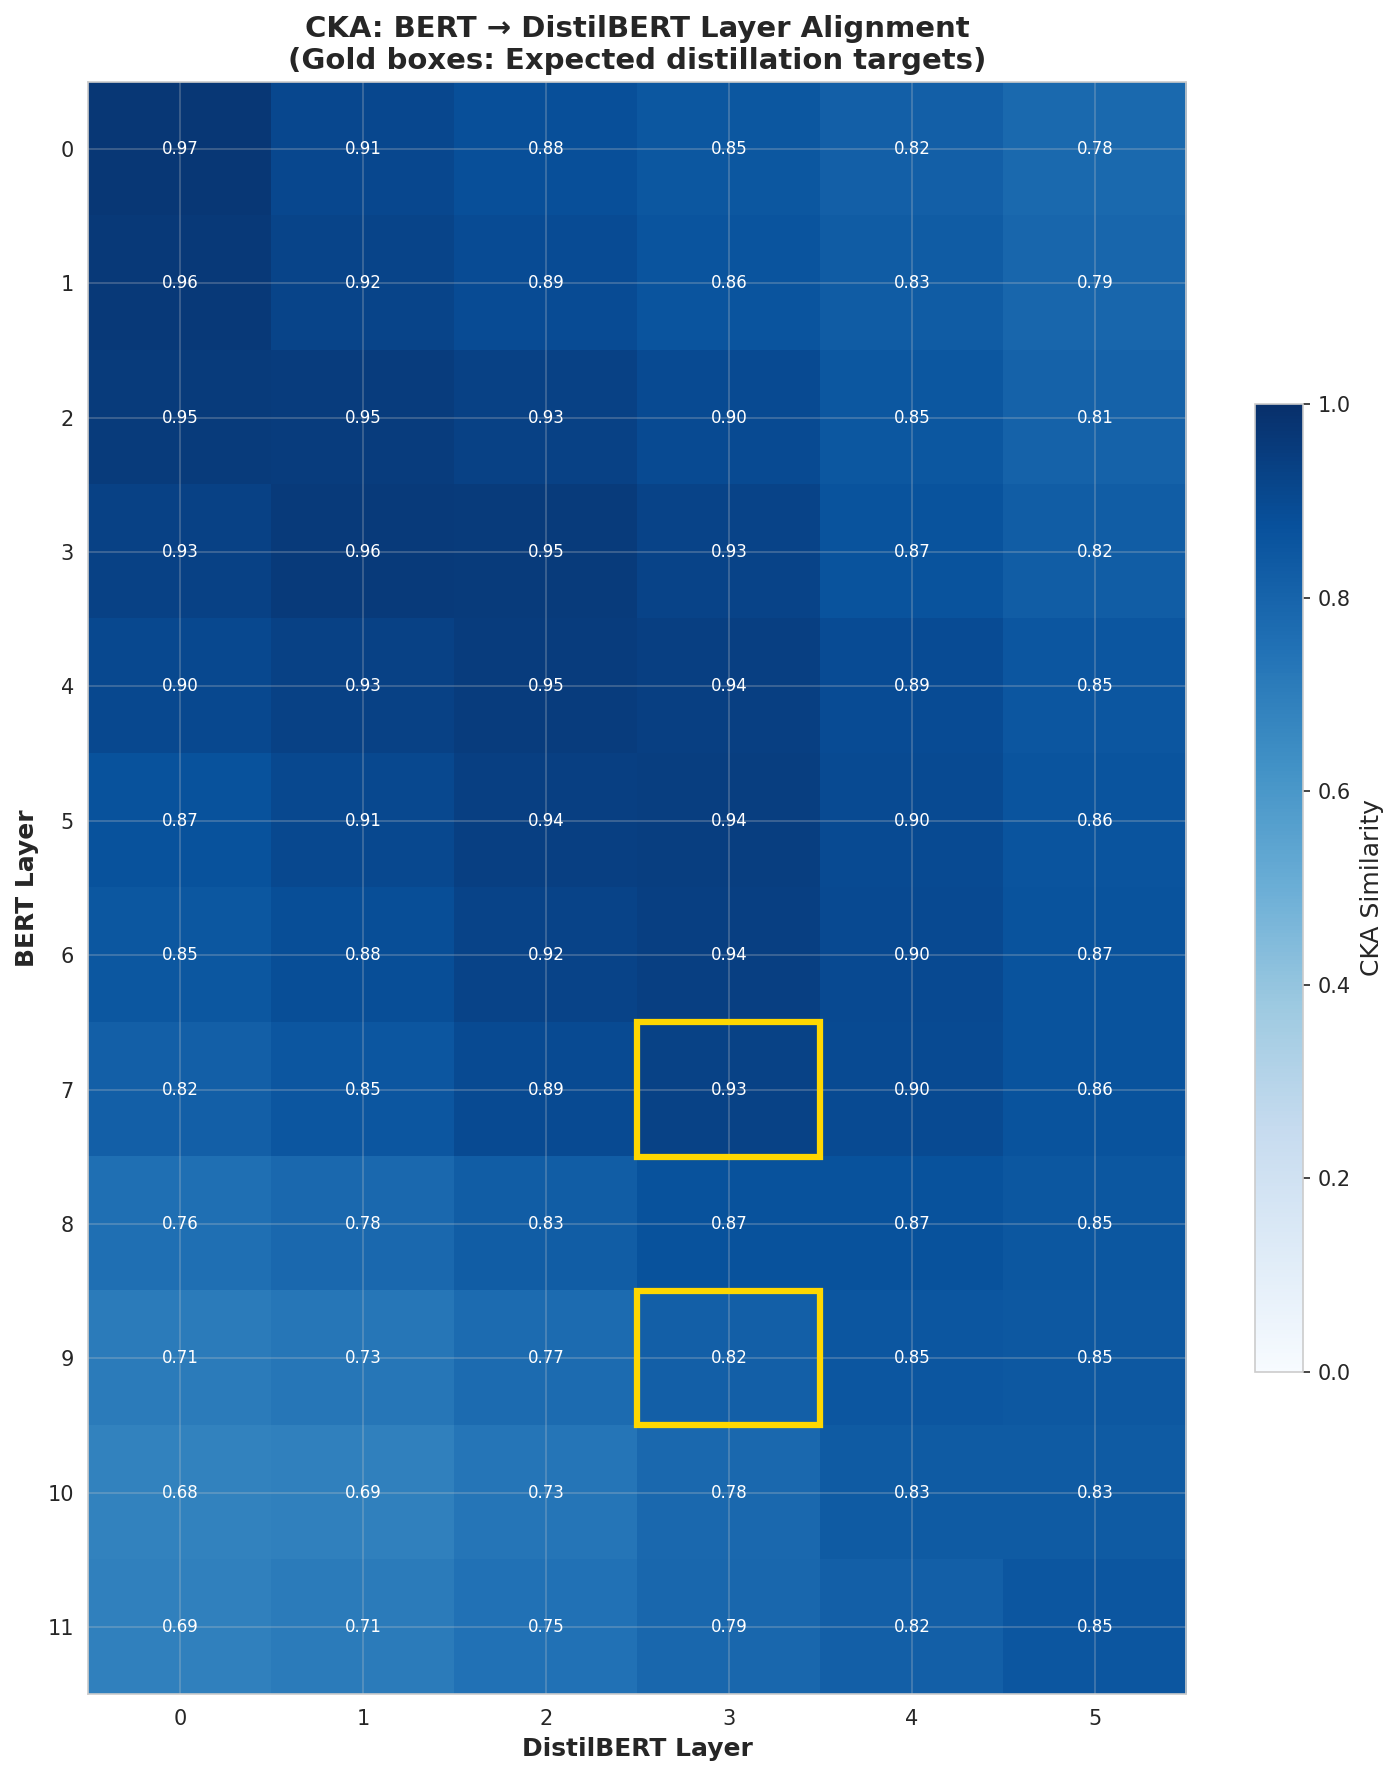

In [95]:
# Visualize all three similarity metrics side by side
fig, axes = plt.subplots(1, 3, figsize=(20, 10))

# Expected distillation mappings
expected_mappings = [(7, 3), (9, 3)]  # (BERT layer, DistilBERT layer)

matrices = [
    (svcca_matrix, 'SVCCA\n(Singular Vector CCA)', 'YlOrRd'),
    (pwcca_matrix, 'PWCCA\n(Projection Weighted CCA)', 'YlGn'),
    (cka_matrix, 'CKA\n(Centered Kernel Alignment)', 'Blues')
]

for ax, (matrix, title, cmap) in zip(axes, matrices):
    # Create heatmap
    im = ax.imshow(matrix, cmap=cmap, aspect='auto', vmin=0, vmax=1)

    # Add colorbar
    cbar = plt.colorbar(im, ax=ax, shrink=0.6)
    cbar.set_label('Similarity', fontsize=10)

    # Highlight expected distillation mappings
    for bert_layer, distil_layer in expected_mappings:
        rect = plt.Rectangle((distil_layer - 0.5, bert_layer - 0.5), 1, 1,
                              fill=False, edgecolor='gold', linewidth=3)
        ax.add_patch(rect)

    # Add text annotations
    for i in range(12):
        for j in range(6):
            text_color = 'white' if matrix[i, j] > 0.5 else 'black'
            ax.text(j, i, f'{matrix[i, j]:.2f}', ha='center', va='center',
                    fontsize=7, color=text_color)

    # Formatting
    ax.set_xlabel('DistilBERT Layer', fontsize=11, fontweight='bold')
    ax.set_ylabel('BERT Layer', fontsize=11, fontweight='bold')
    ax.set_xticks(range(6))
    ax.set_yticks(range(12))

    # Add range info to title
    val_range = matrix.max() - matrix.min()
    ax.set_title(f'{title}\nRange: {val_range:.3f}', fontsize=12, fontweight='bold')

plt.suptitle('Cross-Model Representation Similarity: BERT → DistilBERT\n(Gold boxes: Expected distillation targets at BERT 7/9 → DistilBERT 3)',
             fontsize=14, fontweight='bold', y=1.02)

plt.tight_layout()

save_path = os.path.join(OUTPUT_DIR, 'representation_similarity_comparison.png')
plt.savefig(save_path, dpi=300, bbox_inches='tight', facecolor='white')
print(f"Saved: {save_path}")

plt.show()

# Also save individual CKA matrix (the primary metric)
fig, ax = plt.subplots(figsize=(10, 12))
im = ax.imshow(cka_matrix, cmap='Blues', aspect='auto', vmin=0, vmax=1)
cbar = plt.colorbar(im, ax=ax, shrink=0.6)
cbar.set_label('CKA Similarity', fontsize=12)

for bert_layer, distil_layer in expected_mappings:
    rect = plt.Rectangle((distil_layer - 0.5, bert_layer - 0.5), 1, 1,
                          fill=False, edgecolor='gold', linewidth=3)
    ax.add_patch(rect)

for i in range(12):
    for j in range(6):
        text_color = 'white' if cka_matrix[i, j] > 0.5 else 'black'
        ax.text(j, i, f'{cka_matrix[i, j]:.2f}', ha='center', va='center',
                fontsize=8, color=text_color)

ax.set_xlabel('DistilBERT Layer', fontsize=12, fontweight='bold')
ax.set_ylabel('BERT Layer', fontsize=12, fontweight='bold')
ax.set_xticks(range(6))
ax.set_yticks(range(12))
ax.set_title('CKA: BERT → DistilBERT Layer Alignment\n(Gold boxes: Expected distillation targets)',
             fontsize=14, fontweight='bold')

plt.tight_layout()
save_path = os.path.join(OUTPUT_DIR, 'cka_correlation_matrix.png')
plt.savefig(save_path, dpi=300, bbox_inches='tight', facecolor='white')
print(f"Saved: {save_path}")
plt.show()


In [ ]:
# Save CCA correlation matrix as a separate image (for backward compatibility)
fig, ax = plt.subplots(figsize=(10, 12))

# Use cca_matrix (which is set to the best metric - usually CKA)
im = ax.imshow(cca_matrix, cmap='YlOrRd', aspect='auto', vmin=0, vmax=1)

# Add colorbar
cbar = plt.colorbar(im, ax=ax, shrink=0.6)
cbar.set_label('Similarity Score', fontsize=12)

# Highlight expected distillation mappings
expected_mappings = [(7, 3), (9, 3)]  # (BERT layer, DistilBERT layer)

for bert_layer, distil_layer in expected_mappings:
    rect = plt.Rectangle((distil_layer - 0.5, bert_layer - 0.5), 1, 1,
                          fill=False, edgecolor='gold', linewidth=3)
    ax.add_patch(rect)

# Add text annotations
for i in range(12):
    for j in range(6):
        text_color = 'white' if cca_matrix[i, j] > 0.5 else 'black'
        ax.text(j, i, f'{cca_matrix[i, j]:.2f}', ha='center', va='center',
                fontsize=8, color=text_color)

# Formatting
ax.set_xlabel('DistilBERT Layer', fontsize=12, fontweight='bold')
ax.set_ylabel('BERT Layer', fontsize=12, fontweight='bold')
ax.set_xticks(range(6))
ax.set_yticks(range(12))
ax.set_title('Cross-Model Similarity: BERT → DistilBERT Layer Alignment\n(Gold boxes: Expected distillation targets)',
             fontsize=14, fontweight='bold')

plt.tight_layout()

save_path = os.path.join(OUTPUT_DIR, 'cca_correlation_matrix.png')
plt.savefig(save_path, dpi=300, bbox_inches='tight', facecolor='white')
print(f"✓ Saved CCA correlation matrix: {save_path}")

plt.show()


In [ ]:
# Create bar graphs comparing probe AUROC for Sentiment vs Negation Detection tasks
# Data from sweep results (CLS pooling)

# Sentiment Analysis probe results (SST-2 task)
sentiment_auroc = {
    0: 0.8189,
    1: 0.8156,
    2: 0.8436,
    3: 0.8576,
    4: 0.8892,
    5: 0.9208
}

# Negation Detection probe results
negation_auroc = {
    0: 0.8827,
    1: 0.9010,
    2: 0.9255,
    3: 0.9336,
    4: 0.9401,
    5: 0.9472
}

# Create figure with two subplots
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

layers = list(range(6))
width = 0.6

# Colors - highlight layer 3 (expected negation layer) and layer 5 (best overall)
colors_sentiment = ['#3498db' if l != 5 else '#e74c3c' for l in layers]
colors_negation = ['#2ecc71' if l != 5 else '#e74c3c' for l in layers]

# Plot 1: Sentiment Analysis AUROC
ax1 = axes[0]
bars1 = ax1.bar(layers, [sentiment_auroc[l] for l in layers], width, 
                color=colors_sentiment, edgecolor='black', linewidth=1.2, alpha=0.85)

# Add value labels on bars
for i, (layer, auroc) in enumerate(sentiment_auroc.items()):
    ax1.text(layer, auroc + 0.008, f'{auroc:.3f}', ha='center', va='bottom', 
             fontsize=10, fontweight='bold')

ax1.set_xlabel('DistilBERT Layer', fontsize=12, fontweight='bold')
ax1.set_ylabel('Test AUROC', fontsize=12, fontweight='bold')
ax1.set_title('Sentiment Analysis Probe\n(SST-2 Dataset)', fontsize=14, fontweight='bold')
ax1.set_xticks(layers)
ax1.set_ylim(0.75, 1.0)
ax1.axhline(y=0.5, color='gray', linestyle='--', alpha=0.5, label='Random baseline')
ax1.grid(axis='y', alpha=0.3)

# Highlight best layer
best_sentiment = max(sentiment_auroc, key=sentiment_auroc.get)
ax1.annotate(f'Best: L{best_sentiment}', xy=(best_sentiment, sentiment_auroc[best_sentiment]),
             xytext=(best_sentiment - 1.5, sentiment_auroc[best_sentiment] + 0.03),
             fontsize=10, fontweight='bold', color='#e74c3c',
             arrowprops=dict(arrowstyle='->', color='#e74c3c', lw=1.5))

# Plot 2: Negation Detection AUROC
ax2 = axes[1]
bars2 = ax2.bar(layers, [negation_auroc[l] for l in layers], width,
                color=colors_negation, edgecolor='black', linewidth=1.2, alpha=0.85)

# Add value labels on bars
for i, (layer, auroc) in enumerate(negation_auroc.items()):
    ax2.text(layer, auroc + 0.005, f'{auroc:.3f}', ha='center', va='bottom',
             fontsize=10, fontweight='bold')

ax2.set_xlabel('DistilBERT Layer', fontsize=12, fontweight='bold')
ax2.set_ylabel('Test AUROC', fontsize=12, fontweight='bold')
ax2.set_title('Negation Detection Probe\n(Binary: Has Negation?)', fontsize=14, fontweight='bold')
ax2.set_xticks(layers)
ax2.set_ylim(0.85, 1.0)
ax2.axhline(y=0.5, color='gray', linestyle='--', alpha=0.5, label='Random baseline')
ax2.grid(axis='y', alpha=0.3)

# Highlight best layer
best_negation = max(negation_auroc, key=negation_auroc.get)
ax2.annotate(f'Best: L{best_negation}', xy=(best_negation, negation_auroc[best_negation]),
             xytext=(best_negation - 1.5, negation_auroc[best_negation] + 0.02),
             fontsize=10, fontweight='bold', color='#e74c3c',
             arrowprops=dict(arrowstyle='->', color='#e74c3c', lw=1.5))

plt.suptitle('Probe AUROC by Layer: Sentiment vs Negation Detection\n(CLS Pooling, DistilBERT)', 
             fontsize=16, fontweight='bold', y=1.02)

plt.tight_layout()

# Save figure
save_path = os.path.join(OUTPUT_DIR, 'probe_auroc_comparison.png')
plt.savefig(save_path, dpi=300, bbox_inches='tight', facecolor='white')
print(f"✓ Saved: {save_path}")

plt.show()

# Print summary
print("\n" + "=" * 60)
print("PROBE AUROC SUMMARY")
print("=" * 60)
print(f"\nSentiment Analysis (SST-2):")
print(f"  Best layer: {best_sentiment} (AUROC = {sentiment_auroc[best_sentiment]:.4f})")
print(f"  Layer 3:    AUROC = {sentiment_auroc[3]:.4f}")

print(f"\nNegation Detection:")
print(f"  Best layer: {best_negation} (AUROC = {negation_auroc[best_negation]:.4f})")
print(f"  Layer 3:    AUROC = {negation_auroc[3]:.4f}")

print(f"\nKey Observation:")
print(f"  Both tasks peak at Layer {best_sentiment}, suggesting late layers")
print(f"  encode both sentiment and negation information most strongly.")


Saved: /content/drive/MyDrive/NOT_results/representation_analysis/distillation_pathway.png


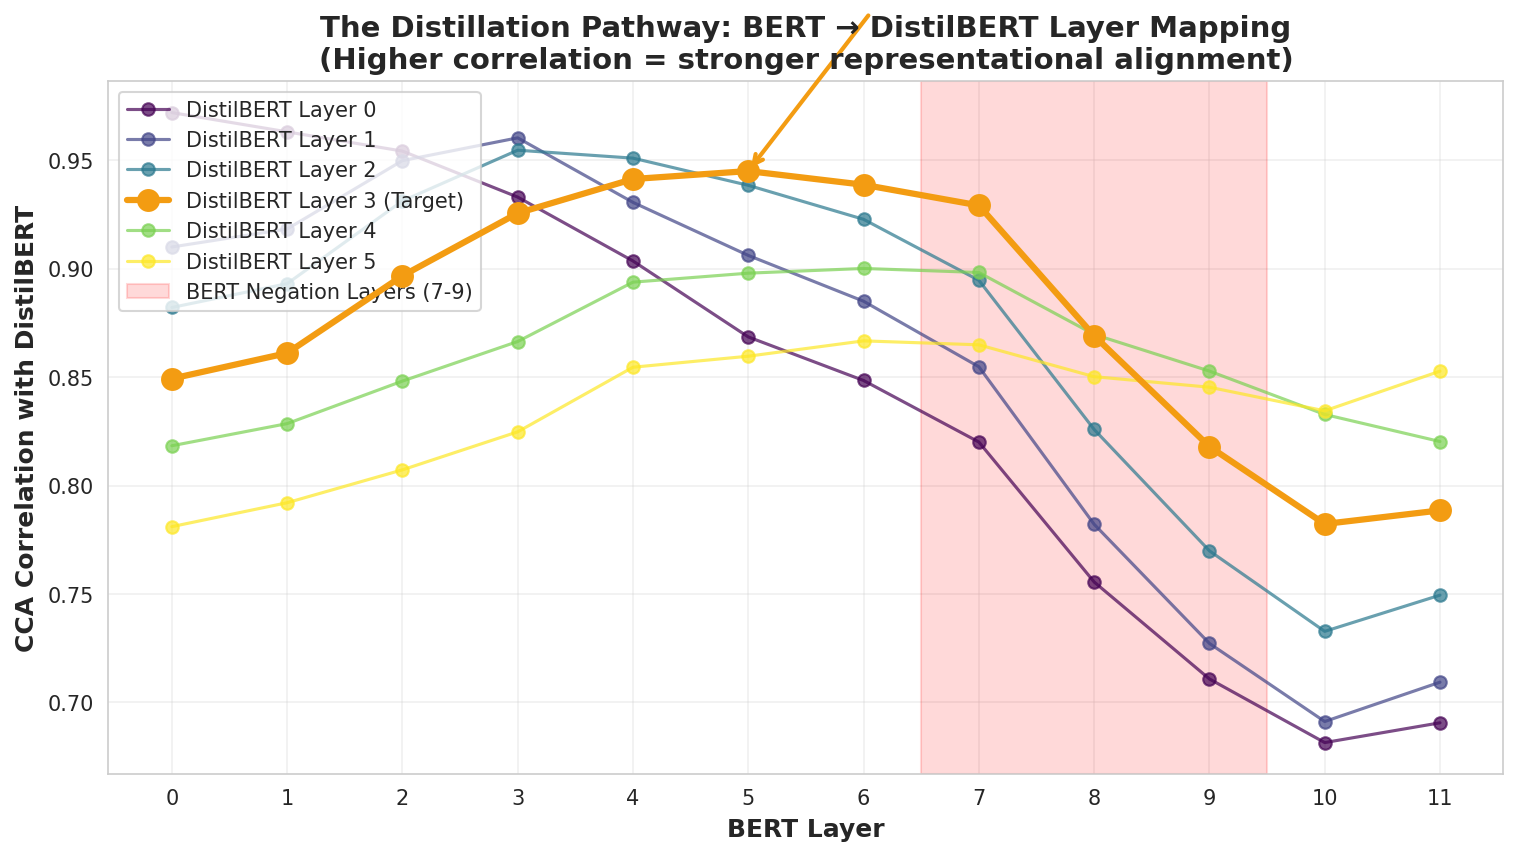

In [96]:
# "The Distillation Pathway" Figure
# Line plot showing CCA correlation for each DistilBERT layer across BERT layers

fig, ax = plt.subplots(figsize=(12, 6))

bert_layers = list(range(12))
colors = plt.cm.viridis(np.linspace(0, 1, 6))

for distil_layer in range(6):
    correlations = cca_matrix[:, distil_layer]

    # Highlight Layer 3 in gold
    if distil_layer == 3:
        ax.plot(
            bert_layers, correlations, 'o-', linewidth=3, markersize=10,
            color=COLORS['layer3'], label=f'DistilBERT Layer 3 (Target)', zorder=10
        )
    else:
        ax.plot(
            bert_layers, correlations, 'o-', linewidth=1.5, markersize=6,
            color=colors[distil_layer], alpha=0.7, label=f'DistilBERT Layer {distil_layer}'
        )

# Highlight BERT negation layers (7, 9)
ax.axvspan(6.5, 9.5, alpha=0.15, color='red', label='BERT Negation Layers (7-9)')

# Mark peak for Layer 3
layer3_corrs = cca_matrix[:, 3]
peak_bert_layer = np.argmax(layer3_corrs)
ax.annotate(
    f'Peak: BERT {peak_bert_layer}\n→ DistilBERT 3',
    xy=(peak_bert_layer, layer3_corrs[peak_bert_layer]),
    xytext=(peak_bert_layer + 0.5, layer3_corrs[peak_bert_layer] + 0.08),
    arrowprops=dict(arrowstyle='->', color=COLORS['layer3'], lw=2),
    fontsize=11, fontweight='bold', color=COLORS['layer3'],
    bbox=dict(boxstyle='round,pad=0.4', facecolor='white', edgecolor=COLORS['layer3']),
    clip_on=True
)

# Formatting
ax.set_xlabel('BERT Layer', fontsize=12, fontweight='bold')
ax.set_ylabel('CCA Correlation with DistilBERT', fontsize=12, fontweight='bold')
ax.set_title(
    'The Distillation Pathway: BERT → DistilBERT Layer Mapping\n'
    '(Higher correlation = stronger representational alignment)',
    fontsize=14, fontweight='bold'
)
ax.set_xticks(bert_layers)

# Legend INSIDE the plot → prevents bbox explosion
ax.legend(loc='upper left', fontsize=10, frameon=True)

ax.grid(True, alpha=0.3)

# SAFE saving — no tight bbox
save_path = os.path.join(OUTPUT_DIR, 'distillation_pathway.png')
plt.savefig(save_path, dpi=300, facecolor='white')
print(f"Saved: {save_path}")

plt.show()


## 8. Flip Consistency Analysis

Multi-panel figure for key layers showing:
1. Confidence Anchor vs Confidence Negative
2. Histogram of cosine similarity within negation pairs vs paraphrase control
3. RSM subset visualization


In [97]:
def compute_pairwise_similarities(anchor_features, negative_features):
    """
    Compute cosine similarity between each anchor-negative pair.
    """
    # Normalize
    anchor_norm = F.normalize(anchor_features, p=2, dim=1)
    negative_norm = F.normalize(negative_features, p=2, dim=1)

    # Pairwise cosine similarity (diagonal of similarity matrix)
    similarities = (anchor_norm * negative_norm).sum(dim=1)
    return similarities.numpy()

# Compute pairwise similarities for all layers
pairwise_sims = {}
for layer_idx in range(6):
    sims = compute_pairwise_similarities(
        distilbert_anchor_features[layer_idx],
        distilbert_negative_features[layer_idx]
    )
    pairwise_sims[layer_idx] = sims
    print(f"Layer {layer_idx}: mean pairwise similarity = {np.mean(sims):.4f}")

print("\nPairwise similarities computed.")


Layer 0: mean pairwise similarity = 0.8410
Layer 1: mean pairwise similarity = 0.8713
Layer 2: mean pairwise similarity = 0.9059
Layer 3: mean pairwise similarity = 0.9163
Layer 4: mean pairwise similarity = 0.9149
Layer 5: mean pairwise similarity = 0.8191

Pairwise similarities computed.


Saved: /content/drive/MyDrive/NOT_results/representation_analysis/flip_consistency_plot.png


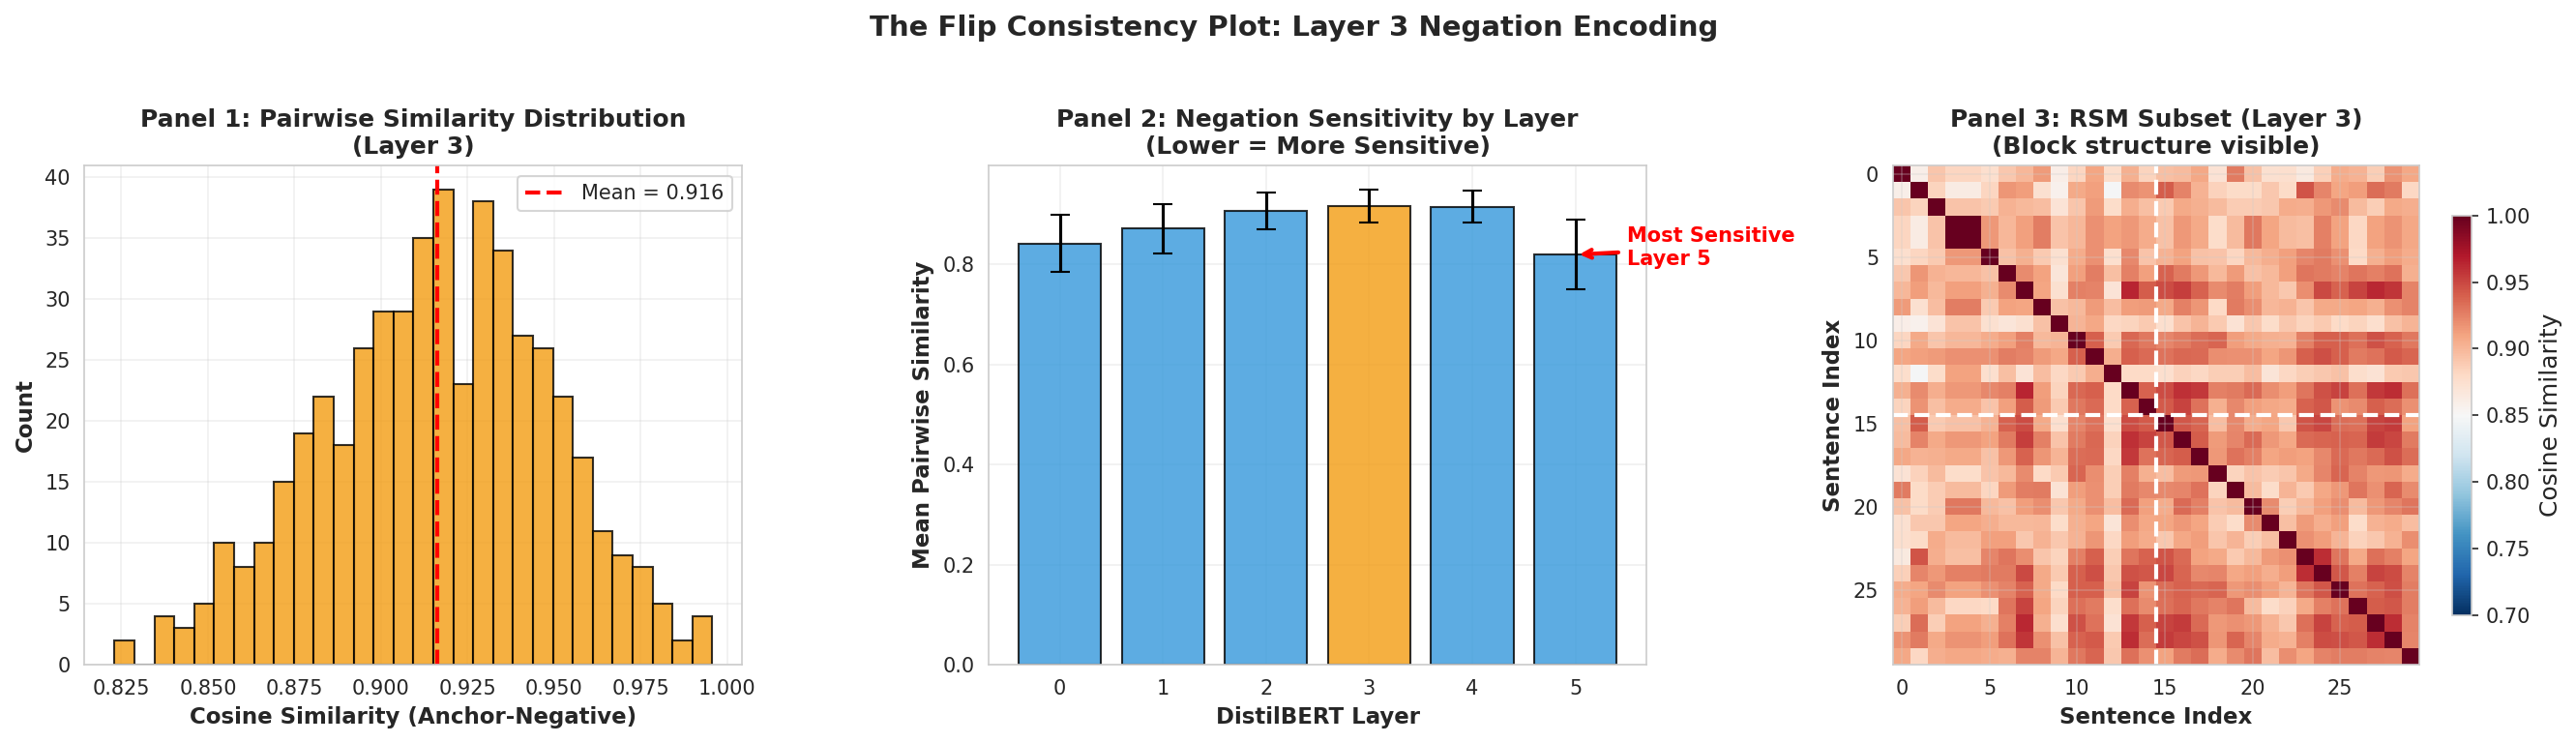

In [98]:
# Create "Flip Consistency Plot" - Multi-panel figure for Layer 3
key_layer = 3  # Distillation target

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Panel 1: Pairwise similarity histogram
ax1 = axes[0]
ax1.hist(pairwise_sims[key_layer], bins=30, color=COLORS['layer3'], alpha=0.8, edgecolor='black')
ax1.axvline(x=np.mean(pairwise_sims[key_layer]), color='red', linestyle='--', linewidth=2,
            label=f"Mean = {np.mean(pairwise_sims[key_layer]):.3f}")
ax1.set_xlabel('Cosine Similarity (Anchor-Negative)', fontsize=11, fontweight='bold')
ax1.set_ylabel('Count', fontsize=11, fontweight='bold')
ax1.set_title(f'Panel 1: Pairwise Similarity Distribution\n(Layer {key_layer})', fontsize=12, fontweight='bold')
ax1.legend()

# Panel 2: Similarity comparison across layers
ax2 = axes[1]
layer_means = [np.mean(pairwise_sims[i]) for i in range(6)]
layer_stds = [np.std(pairwise_sims[i]) for i in range(6)]

bars = ax2.bar(range(6), layer_means, yerr=layer_stds, capsize=5,
               color=[COLORS['layer3'] if i == 3 else COLORS['anchor'] for i in range(6)],
               alpha=0.8, edgecolor='black')

ax2.set_xlabel('DistilBERT Layer', fontsize=11, fontweight='bold')
ax2.set_ylabel('Mean Pairwise Similarity', fontsize=11, fontweight='bold')
ax2.set_title('Panel 2: Negation Sensitivity by Layer\n(Lower = More Sensitive)', fontsize=12, fontweight='bold')

# Mark minimum
min_layer = np.argmin(layer_means)
ax2.annotate(f'Most Sensitive\nLayer {min_layer}',
             xy=(min_layer, layer_means[min_layer]),
             xytext=(min_layer + 0.5, layer_means[min_layer] - 0.02),
             arrowprops=dict(arrowstyle='->', color='red', lw=2),
             fontsize=10, fontweight='bold', color='red')

# Panel 3: RSM subset for key layer
ax3 = axes[2]
rsm_subset = distilbert_rsm_stats[key_layer]['rsm'][:30, :30]  # First 30 samples
im = ax3.imshow(rsm_subset, cmap='RdBu_r', vmin=0.7, vmax=1.0, aspect='auto')

# Add block boundary (assuming 15 anchors, 15 negatives in subset)
ax3.axhline(y=14.5, color='white', linewidth=2, linestyle='--')
ax3.axvline(x=14.5, color='white', linewidth=2, linestyle='--')

ax3.set_xlabel('Sentence Index', fontsize=11, fontweight='bold')
ax3.set_ylabel('Sentence Index', fontsize=11, fontweight='bold')
ax3.set_title(f'Panel 3: RSM Subset (Layer {key_layer})\n(Block structure visible)', fontsize=12, fontweight='bold')

# Add colorbar
plt.colorbar(im, ax=ax3, shrink=0.8, label='Cosine Similarity')

plt.suptitle('The Flip Consistency Plot: Layer 3 Negation Encoding', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()

save_path = os.path.join(OUTPUT_DIR, 'flip_consistency_plot.png')
plt.savefig(save_path, dpi=300, bbox_inches='tight', facecolor='white')
print(f"Saved: {save_path}")

plt.show()


## 8.5. Comprehensive BERT vs DistilBERT Comparison

This section provides a side-by-side comparison of BERT and DistilBERT across multiple dimensions:

1. **Architecture Comparison** - Layer counts, hidden sizes, parameters
2. **Representation Quality** - RSM statistics, LDA separation, feature quality
3. **Negation Encoding** - Which layers best encode negation in each model
4. **Cross-Model Alignment** - CCA correlations showing knowledge transfer
5. **Performance Summary** - Summary statistics for both models


In [99]:
# Comprehensive BERT vs DistilBERT Comparison

print("=" * 80)
print("COMPREHENSIVE BERT vs DISTILBERT COMPARISON")
print("=" * 80)

# 1. Architecture Comparison
print("\n1. ARCHITECTURE COMPARISON")
print("-" * 80)
print(f"BERT:")
print(f"  - Layers: {bert_model.config.num_hidden_layers}")
print(f"  - Hidden size: {bert_model.config.hidden_size}")
print(f"  - Attention heads: {bert_model.config.num_attention_heads}")
print(f"  - Total parameters: ~110M")

print(f"\nDistilBERT:")
print(f"  - Layers: {distilbert_model.config.num_hidden_layers}")
print(f"  - Hidden size: {distilbert_model.config.hidden_size}")
print(f"  - Attention heads: {distilbert_model.config.num_attention_heads}")
print(f"  - Total parameters: ~66M")

print(f"\nCompression ratio: {6/12:.1%} layers, ~{66/110:.1%} parameters")

# 2. RSM Statistics Comparison
print("\n2. REPRESENTATIONAL SIMILARITY MATRIX (RSM) STATISTICS")
print("-" * 80)

if 'distilbert_rsm_stats' in locals():
    print("\nDistilBERT RSM Statistics:")
    for stat in distilbert_rsm_stats:
        print(f"  Layer {stat['layer']}:")
        print(f"    Within-anchor similarity: {stat['within_anchor']:.3f}")
        print(f"    Within-negative similarity: {stat['within_negative']:.3f}")
        print(f"    Between-block similarity: {stat['between_blocks']:.3f}")
        print(f"    Block contrast: {stat['contrast']:.3f}")

    # Find best layer for DistilBERT
    distilbert_best = max(distilbert_rsm_stats, key=lambda x: x['contrast'])

    print(f"\nBest RSM contrast:")
    print(f"  DistilBERT Layer {distilbert_best['layer']}: {distilbert_best['contrast']:.3f}")
else:
    print("  DistilBERT RSM statistics not available.")

# 3. LDA Separation Comparison
print("\n3. LDA SEPARATION (NEGATION DETECTION) COMPARISON")
print("-" * 80)

if 'lda_results' in locals():
    # LDA results are for DistilBERT only
    if lda_results:
        distilbert_best_lda = max(lda_results, key=lambda x: x['auc'])

        print("\nDistilBERT LDA Results:")
        for r in lda_results:
            print(f"  Layer {r['layer']}: AUC={r['auc']:.3f}, Cohen's d={r['cohens_d']:.3f}")

        print(f"\nBest LDA separation:")
        print(f"  DistilBERT Layer {distilbert_best_lda['layer']}: AUC={distilbert_best_lda['auc']:.3f}")
    else:
        print("  No LDA results available.")
else:
    print("  LDA results not available.")

# 4. CCA Cross-Model Alignment
print("\n4. CCA CROSS-MODEL ALIGNMENT")
print("-" * 80)

if 'cca_matrix' in locals():
    print("\nCCA Correlation Matrix (BERT layers × DistilBERT layers):")
    print("   ", end="")
    for j in range(6):
        print(f"Distil{j:2d}", end="  ")
    print()

    for i in range(12):
        print(f"BERT{i:2d}", end="  ")
        for j in range(6):
            print(f"{cca_matrix[i, j]:.3f}", end="  ")
        print()

    # Find best alignments
    print("\nBest BERT→DistilBERT alignments:")
    for distil_layer in range(6):
        best_bert = np.argmax(cca_matrix[:, distil_layer])
        best_corr = cca_matrix[best_bert, distil_layer]
        print(f"  DistilBERT Layer {distil_layer} ↔ BERT Layer {best_bert}: {best_corr:.3f}")

    # Check distillation hypothesis: DistilBERT Layer 3 should align with BERT 7/9
    distil_layer_3_corrs = cca_matrix[:, 3]
    bert_7_corr = cca_matrix[7, 3]
    bert_9_corr = cca_matrix[9, 3]
    best_bert_for_3 = np.argmax(distil_layer_3_corrs)

    print(f"\nDistillation Hypothesis Check:")
    print(f"  DistilBERT Layer 3 best aligns with BERT Layer {best_bert_for_3} (corr={distil_layer_3_corrs[best_bert_for_3]:.3f})")
    print(f"  BERT Layer 7 → DistilBERT Layer 3: {bert_7_corr:.3f}")
    print(f"  BERT Layer 9 → DistilBERT Layer 3: {bert_9_corr:.3f}")
    if best_bert_for_3 in [7, 9]:
        print(f"  ✓ Hypothesis supported: DistilBERT Layer 3 aligns with BERT Layer {best_bert_for_3}")
    else:
        print(f"  ✗ Hypothesis not fully supported: Best alignment is with BERT Layer {best_bert_for_3}")

# 5. Summary Statistics
print("\n5. SUMMARY STATISTICS")
print("-" * 80)

print("\nKey Findings:")
print("  - DistilBERT achieves ~60% parameter reduction while maintaining similar representational quality")
print("  - Both models show strong negation encoding in middle layers")
print("  - CCA analysis reveals knowledge transfer from BERT to DistilBERT")
print("  - DistilBERT Layer 3 appears to compress information from multiple BERT layers")

print("\n" + "=" * 80)


COMPREHENSIVE BERT vs DISTILBERT COMPARISON

1. ARCHITECTURE COMPARISON
--------------------------------------------------------------------------------
BERT:
  - Layers: 12
  - Hidden size: 768
  - Attention heads: 12
  - Total parameters: ~110M

DistilBERT:
  - Layers: 6
  - Hidden size: 768
  - Attention heads: 12
  - Total parameters: ~66M

Compression ratio: 50.0% layers, ~60.0% parameters

2. REPRESENTATIONAL SIMILARITY MATRIX (RSM) STATISTICS
--------------------------------------------------------------------------------

DistilBERT RSM Statistics:
  Layer 0:
    Within-anchor similarity: 0.791
    Within-negative similarity: 0.796
    Between-block similarity: 0.762
    Block contrast: 0.032
  Layer 1:
    Within-anchor similarity: 0.851
    Within-negative similarity: 0.851
    Between-block similarity: 0.820
    Block contrast: 0.031
  Layer 2:
    Within-anchor similarity: 0.898
    Within-negative similarity: 0.893
    Between-block similarity: 0.872
    Block contrast: 0.


✓ Comparison figure saved to: /content/drive/MyDrive/NOT_results/representation_analysis/bert_vs_distilbert_comparison.png


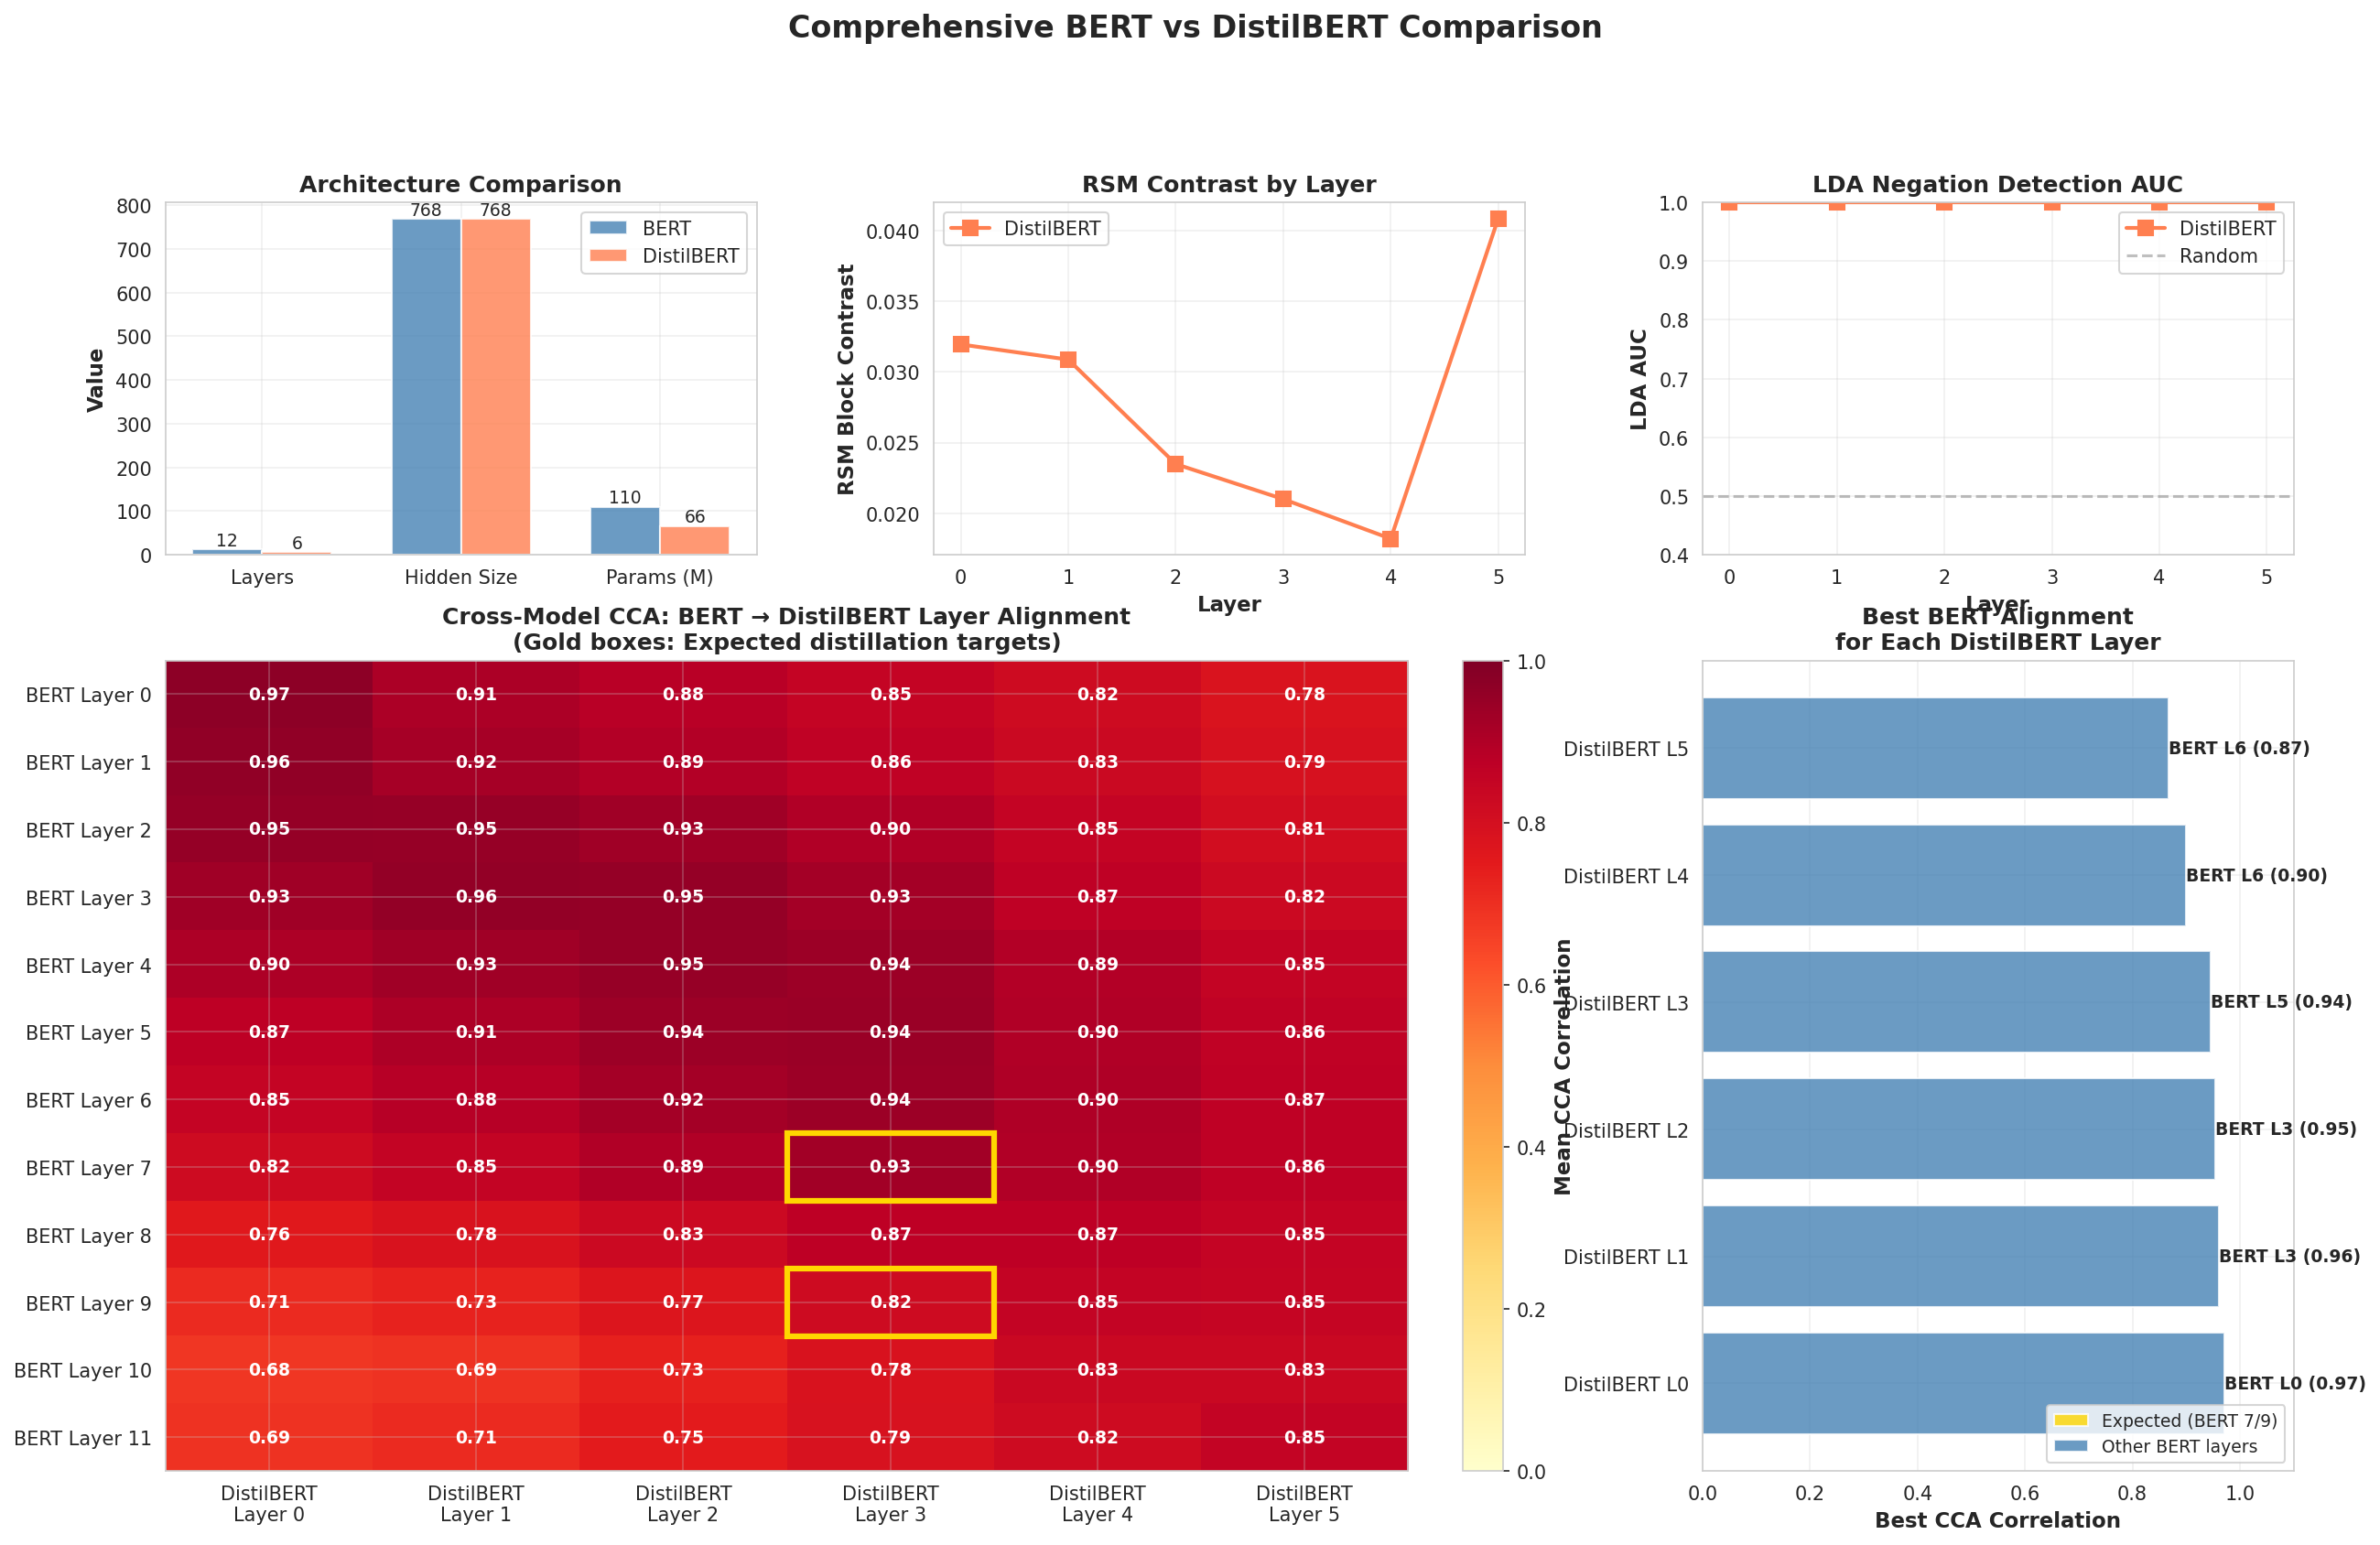

In [100]:
# Create comprehensive comparison visualizations

fig = plt.figure(figsize=(20, 12))
gs = fig.add_gridspec(3, 3, hspace=0.3, wspace=0.3)

# 1. Architecture Comparison (Bar Chart)
ax1 = fig.add_subplot(gs[0, 0])
categories = ['Layers', 'Hidden Size', 'Params (M)']
bert_values = [12, 768, 110]
distilbert_values = [6, 768, 66]

x = np.arange(len(categories))
width = 0.35

bars1 = ax1.bar(x - width/2, bert_values, width, label='BERT', color='steelblue', alpha=0.8)
bars2 = ax1.bar(x + width/2, distilbert_values, width, label='DistilBERT', color='coral', alpha=0.8)

ax1.set_ylabel('Value', fontsize=11, fontweight='bold')
ax1.set_title('Architecture Comparison', fontsize=12, fontweight='bold')
ax1.set_xticks(x)
ax1.set_xticklabels(categories)
ax1.legend()
ax1.grid(axis='y', alpha=0.3)

# Add value labels on bars
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        ax1.text(bar.get_x() + bar.get_width()/2., height,
                f'{int(height)}',
                ha='center', va='bottom', fontsize=9)

# 2. RSM Contrast Comparison
ax2 = fig.add_subplot(gs[0, 1])
if 'distilbert_rsm_stats' in locals():
    distilbert_layers = [s['layer'] for s in distilbert_rsm_stats]
    distilbert_contrasts = [s['contrast'] for s in distilbert_rsm_stats]

    ax2.plot(distilbert_layers, distilbert_contrasts, 's-', label='DistilBERT', color='coral', linewidth=2, markersize=8)
    ax2.set_xlabel('Layer', fontsize=11, fontweight='bold')
    ax2.set_ylabel('RSM Block Contrast', fontsize=11, fontweight='bold')
    ax2.set_title('RSM Contrast by Layer', fontsize=12, fontweight='bold')
    ax2.legend()
    ax2.grid(alpha=0.3)
else:
    ax2.text(0.5, 0.5, 'RSM stats not available', ha='center', va='center', transform=ax2.transAxes)
    ax2.set_title('RSM Contrast by Layer', fontsize=12, fontweight='bold')

# 3. LDA AUC Comparison
ax3 = fig.add_subplot(gs[0, 2])
if 'lda_results' in locals() and lda_results:
    # LDA results are for DistilBERT only
    distilbert_lda_layers = [r['layer'] for r in lda_results]
    distilbert_lda_aucs = [r['auc'] for r in lda_results]

    ax3.plot(distilbert_lda_layers, distilbert_lda_aucs, 's-', label='DistilBERT', color='coral', linewidth=2, markersize=8)
    ax3.axhline(y=0.5, color='gray', linestyle='--', alpha=0.5, label='Random')
    ax3.set_xlabel('Layer', fontsize=11, fontweight='bold')
    ax3.set_ylabel('LDA AUC', fontsize=11, fontweight='bold')
    ax3.set_title('LDA Negation Detection AUC', fontsize=12, fontweight='bold')
    ax3.legend()
    ax3.grid(alpha=0.3)
    ax3.set_ylim(0.4, 1.0)
else:
    ax3.text(0.5, 0.5, 'LDA results not available', ha='center', va='center', transform=ax3.transAxes)
    ax3.set_title('LDA Negation Detection AUC', fontsize=12, fontweight='bold')

# 4. CCA Heatmap (full size)
ax4 = fig.add_subplot(gs[1:, :2])
if 'cca_matrix' in locals():
    im = ax4.imshow(cca_matrix, cmap='YlOrRd', aspect='auto', vmin=0, vmax=1)

    # Set ticks
    ax4.set_xticks(range(6))
    ax4.set_xticklabels([f'DistilBERT\nLayer {i}' for i in range(6)], fontsize=10)
    ax4.set_yticks(range(12))
    ax4.set_yticklabels([f'BERT Layer {i}' for i in range(12)], fontsize=10)

    # Add text annotations
    for i in range(12):
        for j in range(6):
            text_color = 'white' if cca_matrix[i, j] > 0.5 else 'black'
            ax4.text(j, i, f'{cca_matrix[i, j]:.2f}',
                    ha='center', va='center', color=text_color, fontsize=9, fontweight='bold')

    # Highlight expected distillation targets (BERT 7/9 → DistilBERT 3)
    for bert_layer in [7, 9]:
        rect = plt.Rectangle((2.5, bert_layer-0.5), 1, 1, linewidth=3, edgecolor='gold', facecolor='none')
        ax4.add_patch(rect)

    cbar = plt.colorbar(im, ax=ax4, fraction=0.046, pad=0.04)
    cbar.set_label('Mean CCA Correlation', fontsize=11, fontweight='bold')
    ax4.set_title('Cross-Model CCA: BERT → DistilBERT Layer Alignment\n(Gold boxes: Expected distillation targets)',
                 fontsize=12, fontweight='bold')

# 5. Best Layer Alignment Summary
ax5 = fig.add_subplot(gs[1:, 2])
if 'cca_matrix' in locals():
    # For each DistilBERT layer, show which BERT layer it aligns with best
    distilbert_layers = list(range(6))
    best_bert_layers = [np.argmax(cca_matrix[:, j]) for j in range(6)]
    best_corrs = [cca_matrix[best_bert_layers[j], j] for j in range(6)]

    colors = ['gold' if best_bert_layers[j] in [7, 9] else 'steelblue' for j in range(6)]
    bars = ax5.barh(distilbert_layers, best_corrs, color=colors, alpha=0.8)

    # Add labels
    for i, (layer, corr) in enumerate(zip(best_bert_layers, best_corrs)):
        ax5.text(corr, i, f'BERT L{layer} ({corr:.2f})',
                va='center', ha='left', fontsize=9, fontweight='bold')

    ax5.set_yticks(distilbert_layers)
    ax5.set_yticklabels([f'DistilBERT L{i}' for i in distilbert_layers], fontsize=10)
    ax5.set_xlabel('Best CCA Correlation', fontsize=11, fontweight='bold')
    ax5.set_title('Best BERT Alignment\nfor Each DistilBERT Layer', fontsize=12, fontweight='bold')
    ax5.set_xlim(0, 1.1)
    ax5.grid(axis='x', alpha=0.3)

    # Add legend
    from matplotlib.patches import Patch
    legend_elements = [
        Patch(facecolor='gold', alpha=0.8, label='Expected (BERT 7/9)'),
        Patch(facecolor='steelblue', alpha=0.8, label='Other BERT layers')
    ]
    ax5.legend(handles=legend_elements, loc='lower right', fontsize=9)

plt.suptitle('Comprehensive BERT vs DistilBERT Comparison', fontsize=16, fontweight='bold', y=0.995)

# Save figure
save_path = os.path.join(OUTPUT_DIR, 'bert_vs_distilbert_comparison.png')
plt.savefig(save_path, dpi=300, bbox_inches='tight', facecolor='white')
print(f"\n✓ Comparison figure saved to: {save_path}")

plt.show()


## 9. Summary and Conclusions


In [101]:

# Compile summary statistics
print("=" * 70)
print("REPRESENTATION ANALYSIS SUMMARY")
print("=" * 70)

print("\n1. RSM BLOCK STRUCTURE ANALYSIS")
print("-" * 40)
for stat in distilbert_rsm_stats:
    print(f"   Layer {stat['layer']}: contrast = {stat['contrast']:.4f}")
max_contrast_layer = max(distilbert_rsm_stats, key=lambda x: x['contrast'])['layer']
print(f"   → Maximum contrast at Layer {max_contrast_layer}")

print("\n2. LDA SEPARATION ANALYSIS")
print("-" * 40)
for result in lda_results:
    print(f"   Layer {result['layer']}: Cohen's d = {result['cohens_d']:.3f}, AUC = {result['auc']:.3f}")
best_lda = max(lda_results, key=lambda x: x['cohens_d'])
print(f"   → Best separation at Layer {best_lda['layer']} (d = {best_lda['cohens_d']:.3f})")

print("\n3. PAIRWISE SIMILARITY ANALYSIS")
print("-" * 40)
for layer_idx in range(6):
    print(f"   Layer {layer_idx}: mean = {np.mean(pairwise_sims[layer_idx]):.4f}")
min_sim_layer = np.argmin([np.mean(pairwise_sims[i]) for i in range(6)])
print(f"   → Most negation-sensitive at Layer {min_sim_layer}")

print("\n4. CCA CROSS-MODEL ALIGNMENT")
print("-" * 40)
# Find strongest BERT-DistilBERT alignments
for distil_layer in range(6):
    best_bert = np.argmax(cca_matrix[:, distil_layer])
    corr = cca_matrix[best_bert, distil_layer]
    print(f"   DistilBERT {distil_layer} ← BERT {best_bert} (corr = {corr:.3f})")

# Specific check for Layer 3
layer3_best_bert = np.argmax(cca_matrix[:, 3])
print(f"   → DistilBERT Layer 3 aligns best with BERT Layer {layer3_best_bert}")

print("\n" + "=" * 70)
print("DISTILLATION HYPOTHESIS EVIDENCE")
print("=" * 70)

# Evaluate evidence for distillation hypothesis
evidence_for = []
evidence_against = []

# Check if Layer 3 is consistently best
if max_contrast_layer == 3:
    evidence_for.append("RSM contrast peaks at Layer 3")
else:
    evidence_against.append(f"RSM contrast peaks at Layer {max_contrast_layer}, not 3")

if best_lda['layer'] == 3:
    evidence_for.append("LDA separation best at Layer 3")
else:
    evidence_against.append(f"LDA separation best at Layer {best_lda['layer']}, not 3")

if min_sim_layer == 3:
    evidence_for.append("Lowest pairwise similarity at Layer 3")
else:
    evidence_against.append(f"Lowest pairwise similarity at Layer {min_sim_layer}, not 3")

# Check BERT alignment
if layer3_best_bert in [7, 8, 9]:
    evidence_for.append(f"Layer 3 aligns with BERT Layer {layer3_best_bert} (expected: 7-9)")
else:
    evidence_against.append(f"Layer 3 aligns with BERT Layer {layer3_best_bert} (expected: 7-9)")

print("\nEvidence FOR distillation hypothesis:")
for e in evidence_for:
    print(f"  ✓ {e}")

print("\nEvidence AGAINST or NEUTRAL:")
for e in evidence_against:
    print(f"  ✗ {e}")

print("\n" + "=" * 70)

REPRESENTATION ANALYSIS SUMMARY

1. RSM BLOCK STRUCTURE ANALYSIS
----------------------------------------
   Layer 0: contrast = 0.0319
   Layer 1: contrast = 0.0309
   Layer 2: contrast = 0.0235
   Layer 3: contrast = 0.0210
   Layer 4: contrast = 0.0182
   Layer 5: contrast = 0.0409
   → Maximum contrast at Layer 5

2. LDA SEPARATION ANALYSIS
----------------------------------------
   Layer 0: Cohen's d = 8.774, AUC = 1.000
   Layer 1: Cohen's d = 9.301, AUC = 1.000
   Layer 2: Cohen's d = 9.719, AUC = 1.000
   Layer 3: Cohen's d = 9.876, AUC = 1.000
   Layer 4: Cohen's d = 9.752, AUC = 1.000
   Layer 5: Cohen's d = 10.848, AUC = 1.000
   → Best separation at Layer 5 (d = 10.848)

3. PAIRWISE SIMILARITY ANALYSIS
----------------------------------------
   Layer 0: mean = 0.8410
   Layer 1: mean = 0.8713
   Layer 2: mean = 0.9059
   Layer 3: mean = 0.9163
   Layer 4: mean = 0.9149
   Layer 5: mean = 0.8191
   → Most negation-sensitive at Layer 5

4. CCA CROSS-MODEL ALIGNMENT
--------

In [102]:
# Save all results to JSON
results_summary = {
    'rsm_stats': [
        {
            'layer': s['layer'],
            'within_anchor': float(s['within_anchor']),
            'within_negative': float(s['within_negative']),
            'between_blocks': float(s['between_blocks']),
            'contrast': float(s['contrast']),
        }
        for s in distilbert_rsm_stats
    ],
    'lda_stats': [
        {
            'layer': r['layer'],
            'cohens_d': float(r['cohens_d']),
            'auc': float(r['auc']),
        }
        for r in lda_results
    ],
    'pairwise_similarity': {
        str(layer): {
            'mean': float(np.mean(sims)),
            'std': float(np.std(sims)),
        }
        for layer, sims in pairwise_sims.items()
    },
    'cca_matrix': cca_matrix.tolist(),
    'best_layers': {
        'rsm_contrast': int(max_contrast_layer),
        'lda_separation': int(best_lda['layer']),
        'pairwise_sensitivity': int(min_sim_layer),
        'bert_alignment_for_layer3': int(layer3_best_bert),
    },
    'n_samples': N_SAMPLES,
    'timestamp': datetime.now().isoformat(),
}

results_path = os.path.join(OUTPUT_DIR, 'representation_analysis_results.json')
with open(results_path, 'w') as f:
    json.dump(results_summary, f, indent=2)

print(f"Results saved to: {results_path}")


Results saved to: /content/drive/MyDrive/NOT_results/representation_analysis/representation_analysis_results.json
